# Stratified Sampling

Two-level stratification:
1. **CO$_2$ bin** — discrete levels from pool generation
2. **Impurity cluster** — min-max scale the impurity vector, then k-means

Strata = CO$_2$_bin × impurity_cluster. Proportional allocation per stratum, 20 independent trials × 5 sizes.

In [1]:
import  numpy as np
import  pandas as pd
import  matplotlib.pyplot as plt
import  seaborn as sns
import  thermoift.PLOT_SETTINGS as ps
from    pathlib import Path
from    sklearn.cluster import KMeans
from    sklearn.preprocessing import MinMaxScaler
from    thermoift.rng_utils import get_rng
from    sklearn.decomposition import PCA
from    sklearn.metrics import silhouette_score

In [2]:
# ── CONFIG ────────────────────────────────────────────────────────────────────────────
POOL_PATH  = Path("POOL/composition_pool.csv")
OUTPUT_DIR = Path("Stratified_Sampling")

N_SIZES    = [25, 50, 75, 100]
N_TRIALS   = 20
BASE_SEED  = 770077
RNG_TYPE   = "PCG64"

# CO_2 bins (same as pool generation convention)
CO2_BINS   = [0.95, 0.96, 0.97, 0.98, 0.99, 1.001]
CO2_LABELS = ["0.95-0.96", "0.96-0.97", "0.97-0.98", "0.98-0.99", "0.99-1.00"]

IMPURITY_COLS = ["H2", "Ar", "N2", "CH4", "O2", "CO", "H2S"]
K_IMP         = 5       # number of impurity clusters
KMEANS_SEED   = BASE_SEED

# ── Plot style overrides ─────────────────────────────────────────────────────
PLOT_FONT_FAMILY = ps.graphic_font
PLOT_LABEL_FONTSIZE = ps.label_fontsize
PLOT_TICK_LABELSIZE = ps.tick_labelsize + 2
PLOT_LEGEND_FONTSIZE = ps.legend_fontsize
DIAGNOSTIC_MARKERSIZE = ps.markersize + 1
DIAGNOSTIC_MARKEREDGEWIDTH = ps.markeredgewidth + 0.4
DIAGNOSTIC_MARKERFACE_ALPHA = 0.18

ps.graphic_font = PLOT_FONT_FAMILY
ps.label_fontsize = PLOT_LABEL_FONTSIZE
ps.tick_labelsize = PLOT_TICK_LABELSIZE
ps.legend_fontsize = PLOT_LEGEND_FONTSIZE

# ── Load pool ───────────────────────────────────────────────────────────────────────────
pool = pd.read_csv(POOL_PATH)
print(f"Pool: {len(pool):,} compositions")

Pool: 1,000 compositions


In [3]:
# ── Step 1: CO_2 binning ───────────────────────────────────────────────────────
pool["CO2_round"] = pool["CO2"].round(4)
pool["co2_bin"]   = pd.cut(
    pool["CO2_round"],
    bins=CO2_BINS,
    labels=CO2_LABELS,
    right=False
)
print("CO_2 bin counts:")
print(pool["co2_bin"].value_counts().sort_index().to_string())

CO_2 bin counts:
co2_bin
0.95-0.96    245
0.96-0.97    191
0.97-0.98    199
0.98-0.99    183
0.99-1.00    182


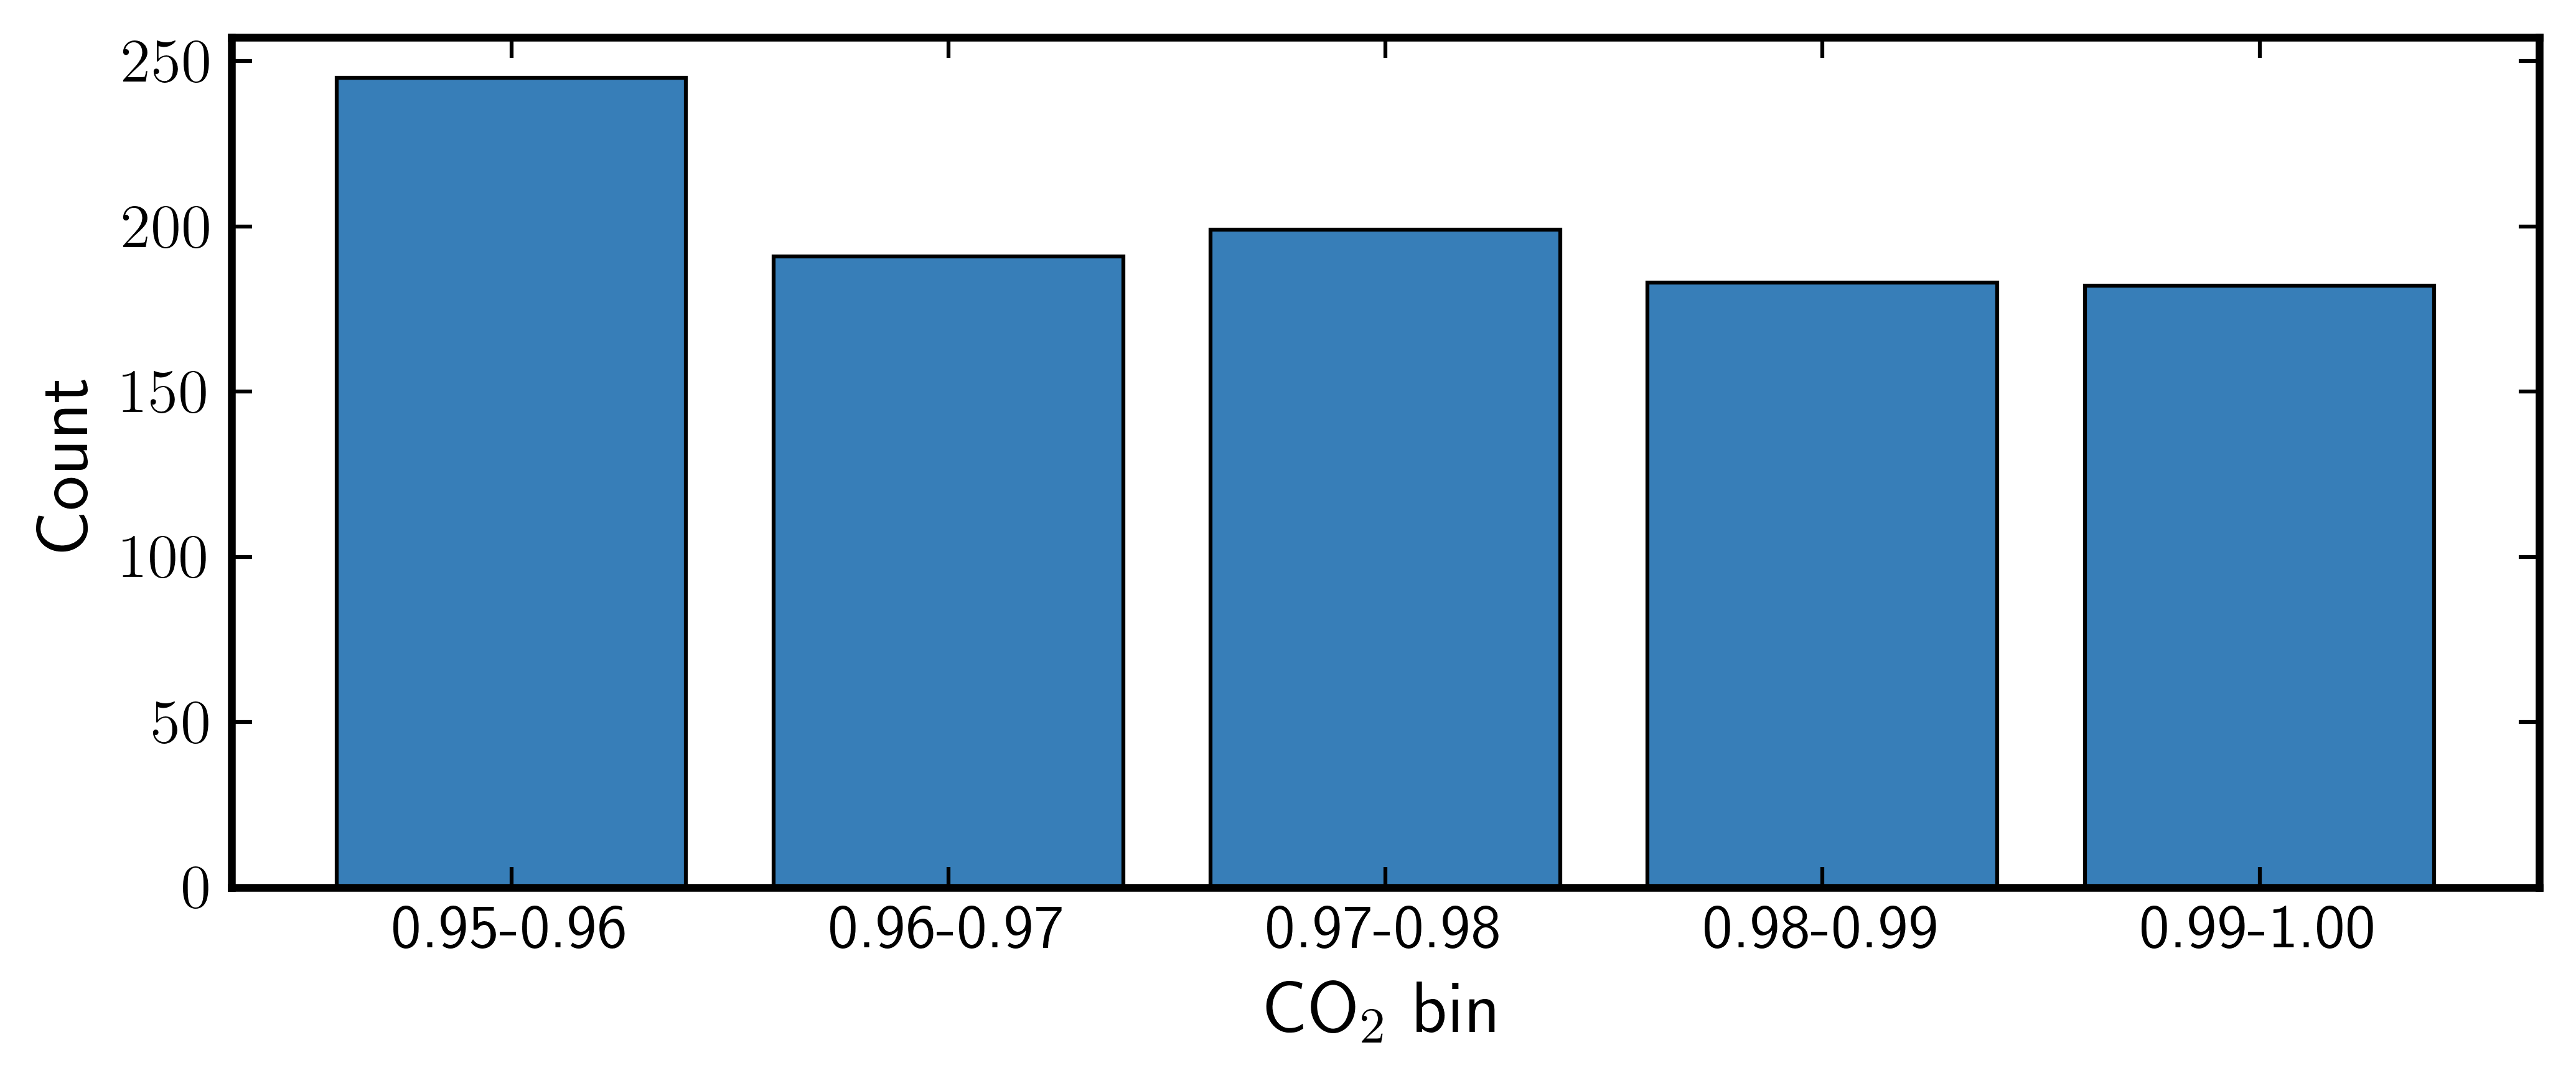

In [4]:
# ── Plot: CO_2 bin distribution ────────────────────────────────────────────────
fig, ax = ps.plot_init(w=7, h=3)
counts = pool["co2_bin"].value_counts().sort_index()
ax.bar(
    counts.index.astype(str),
    counts.values,
    color=ps.colors[2],
    edgecolor="black",
    linewidth=ps.markeredgewidth,
)
ax.set_xlabel(r"CO$_2$ bin", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("Count", fontsize=PLOT_LABEL_FONTSIZE)
fig.tight_layout()
plt.show()

In [5]:
# ── Step 2: Per-bin impurity scaling + k-means ───────────────────────────────
pool["imp_cluster"] = -1

scalers_per_bin = {}
kmeans_per_bin  = {}

for b in CO2_LABELS:
    mask = pool["co2_bin"] == b
    if mask.sum() == 0:
        continue
    sub = pool.loc[mask]

    # normalise impurity pattern relative to total impurity
    x_imp_total = (1.0 - sub["CO2"].values).reshape(-1, 1)
    X_imp_norm  = sub[IMPURITY_COLS].values / np.clip(x_imp_total, 1e-12, None)

    sc       = MinMaxScaler()
    X_bin_sc = sc.fit_transform(X_imp_norm)

    k_local = min(K_IMP, mask.sum())
    km      = KMeans(n_clusters=k_local, random_state=KMEANS_SEED, n_init=20)
    pool.loc[mask, "imp_cluster"] = km.fit_predict(X_bin_sc)

    scalers_per_bin[b] = sc
    kmeans_per_bin[b]  = km

n_unassigned = (pool["imp_cluster"] == -1).sum()
if n_unassigned:
    print(f"Warning: {n_unassigned} rows unassigned (NaN co2_bin?)")
else:
    print("All compositions assigned to a cluster.")

cluster_table = (
    pool.loc[pool["imp_cluster"] != -1]
        .groupby(["co2_bin", "imp_cluster"], observed=True)
        .size()
        .unstack(fill_value=0)
)
print(f"\nImpurity cluster counts within each CO_2 bin (K={K_IMP}):")
print(cluster_table.to_string())

All compositions assigned to a cluster.

Impurity cluster counts within each CO_2 bin (K=5):
imp_cluster   0   1   2   3   4
co2_bin                        
0.95-0.96    42  41  44  55  63
0.96-0.97    27  25  62  33  44
0.97-0.98    40  39  26  66  28
0.98-0.99    38  22  28  59  36
0.99-1.00    33  48  36  28  37


In [6]:
cluster_summary = []

for co2_bin in CO2_LABELS:
    if co2_bin not in scalers_per_bin:
        continue

    scaler = scalers_per_bin[co2_bin]
    kmeans = kmeans_per_bin[co2_bin]

    centers = scaler.inverse_transform(kmeans.cluster_centers_)

    centers_df = pd.DataFrame(centers, columns=IMPURITY_COLS)
    centers_df["co2_bin"] = co2_bin
    centers_df["imp_cluster"] = range(kmeans.n_clusters)

    # Number of compositions assigned to each cluster in this CO_2 bin
    counts = (
        pool.loc[pool["co2_bin"] == co2_bin, "imp_cluster"]
        .value_counts()
        .sort_index()
    )

    centers_df["n_points"] = centers_df["imp_cluster"].map(counts).fillna(0).astype(int)

    # Dominant impurity species
    centers_df["dominant_impurity"] = centers_df[IMPURITY_COLS].idxmax(axis=1)
    centers_df["dominant_fraction"] = centers_df[IMPURITY_COLS].max(axis=1)

    # Second most important impurity species
    second_species = []
    second_fraction = []

    for _, row in centers_df.iterrows():
        sorted_vals = row[IMPURITY_COLS].sort_values(ascending=False)
        second_species.append(sorted_vals.index[1])
        second_fraction.append(sorted_vals.iloc[1])

    centers_df["second_impurity"] = second_species
    centers_df["second_fraction"] = second_fraction

    cluster_summary.append(centers_df)

cluster_summary_df = pd.concat(cluster_summary, ignore_index=True)

cluster_summary_df[
    [
        "co2_bin", "imp_cluster", "n_points",
        "dominant_impurity", "dominant_fraction",
        "second_impurity", "second_fraction",
        *IMPURITY_COLS
    ]
]

,co2_bin,imp_cluster,n_points,dominant_impurity,dominant_fraction,second_impurity,second_fraction,H2,Ar,N2,CH4,O2,CO,H2S
0,0.95-0.96,0,42,Ar,0.569493,CO,0.093677,0.054637,0.569493,0.079227,0.047277,0.079865,0.093677,0.075824
1,0.95-0.96,1,41,H2S,0.604567,CH4,0.119050,0.044700,0.048300,0.050250,0.119050,0.051000,0.082133,0.604567
2,0.95-0.96,2,44,H2,0.609516,CO,0.086189,0.609516,0.052340,0.044899,0.067051,0.059885,0.086189,0.080120
3,0.95-0.96,3,55,O2,0.389941,CO,0.321587,0.055996,0.054469,0.055069,0.071443,0.389941,0.321587,0.051494
4,0.95-0.96,4,63,CH4,0.358601,N2,0.341722,0.112187,0.041871,0.341722,0.358601,0.079389,0.040238,0.025992
5,0.96-0.97,0,27,H2,0.760651,N2,0.065094,0.760651,0.028708,0.065094,0.018241,0.046707,0.042302,0.038297
6,0.96-0.97,1,25,CH4,0.685123,CO,0.079783,0.049165,0.060364,0.012569,0.685123,0.054686,0.079783,0.058310
7,0.96-0.97,2,62,H2S,0.290148,Ar,0.282193,0.064260,0.282193,0.058321,0.047207,0.059968,0.197904,0.290148
8,0.96-0.97,3,33,O2,0.630312,CO,0.132369,0.052331,0.046996,0.057817,0.052412,0.630312,0.132369,0.027763
9,0.96-0.97,4,44,N2,0.577362,O2,0.093714,0.075574,0.068024,0.577362,0.083927,0.093714,0.038427,0.062972


In [7]:
K_values = range(2, 12)

rows = []

for b in CO2_LABELS:
    mask = pool["co2_bin"] == b
    sub = pool.loc[mask]

    if len(sub) < 5:
        continue

    x_imp_total = (1.0 - sub["CO2"].values).reshape(-1, 1)
    X_imp_norm = sub[IMPURITY_COLS].values / np.clip(x_imp_total, 1e-12, None)

    sc = MinMaxScaler()
    X_bin_sc = sc.fit_transform(X_imp_norm)

    for k in K_values:
        if k >= len(sub):
            continue

        km = KMeans(
            n_clusters=k,
            random_state=KMEANS_SEED,
            n_init=20
        )

        labels = km.fit_predict(X_bin_sc)

        inertia = km.inertia_
        silhouette = silhouette_score(X_bin_sc, labels)

        counts = pd.Series(labels).value_counts()
        min_cluster_size = counts.min()

        rows.append({
            "co2_bin": b,
            "K": k,
            "n_points": len(sub),
            "inertia": inertia,
            "silhouette": silhouette,
            "min_cluster_size": min_cluster_size
        })

k_diagnostics = pd.DataFrame(rows)
k_diagnostics

,co2_bin,K,n_points,inertia,silhouette,min_cluster_size
0,0.95-0.96,2,245,77.340039,0.149131,56
1,0.95-0.96,3,245,65.216155,0.195051,46
2,0.95-0.96,4,245,54.737245,0.234574,41
3,0.95-0.96,5,245,45.390818,0.274224,41
4,0.95-0.96,6,245,35.639416,0.324370,32
5,0.95-0.96,7,245,26.456744,0.372666,24
6,0.95-0.96,8,245,24.269841,0.343167,22
7,0.95-0.96,9,245,22.714915,0.329449,16
8,0.95-0.96,10,245,21.453306,0.326098,10
9,0.95-0.96,11,245,20.483654,0.297585,16


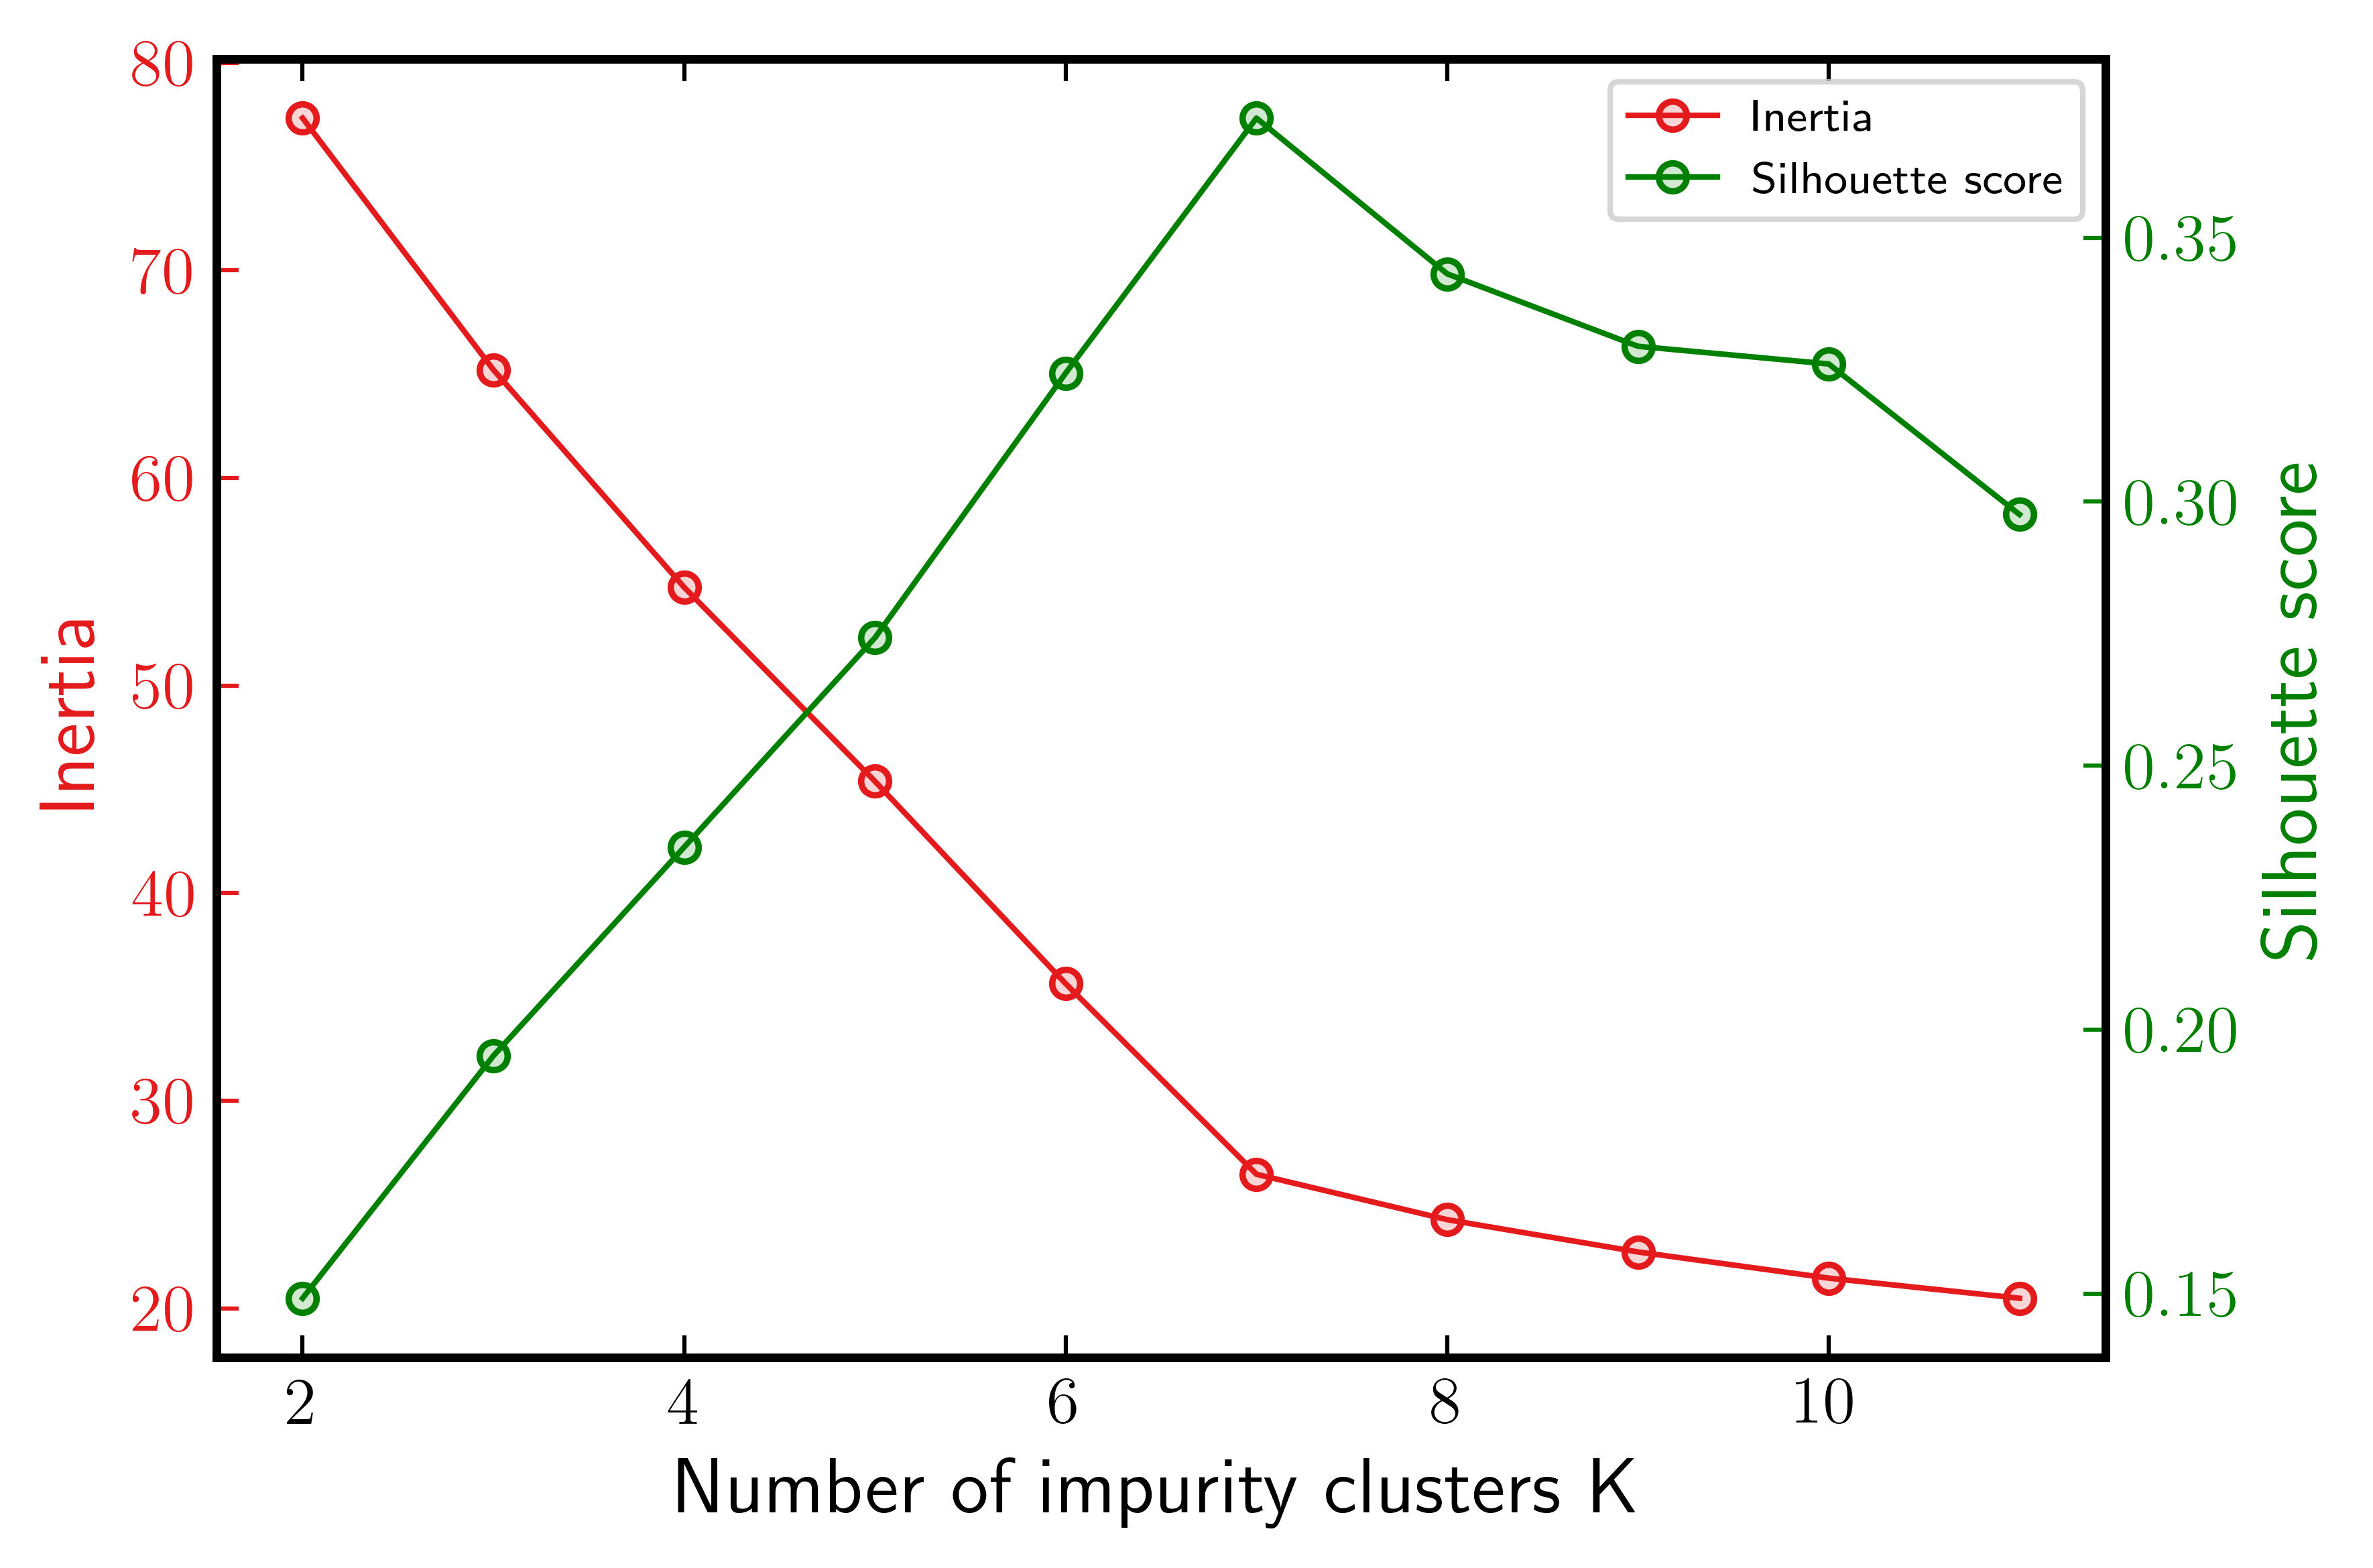

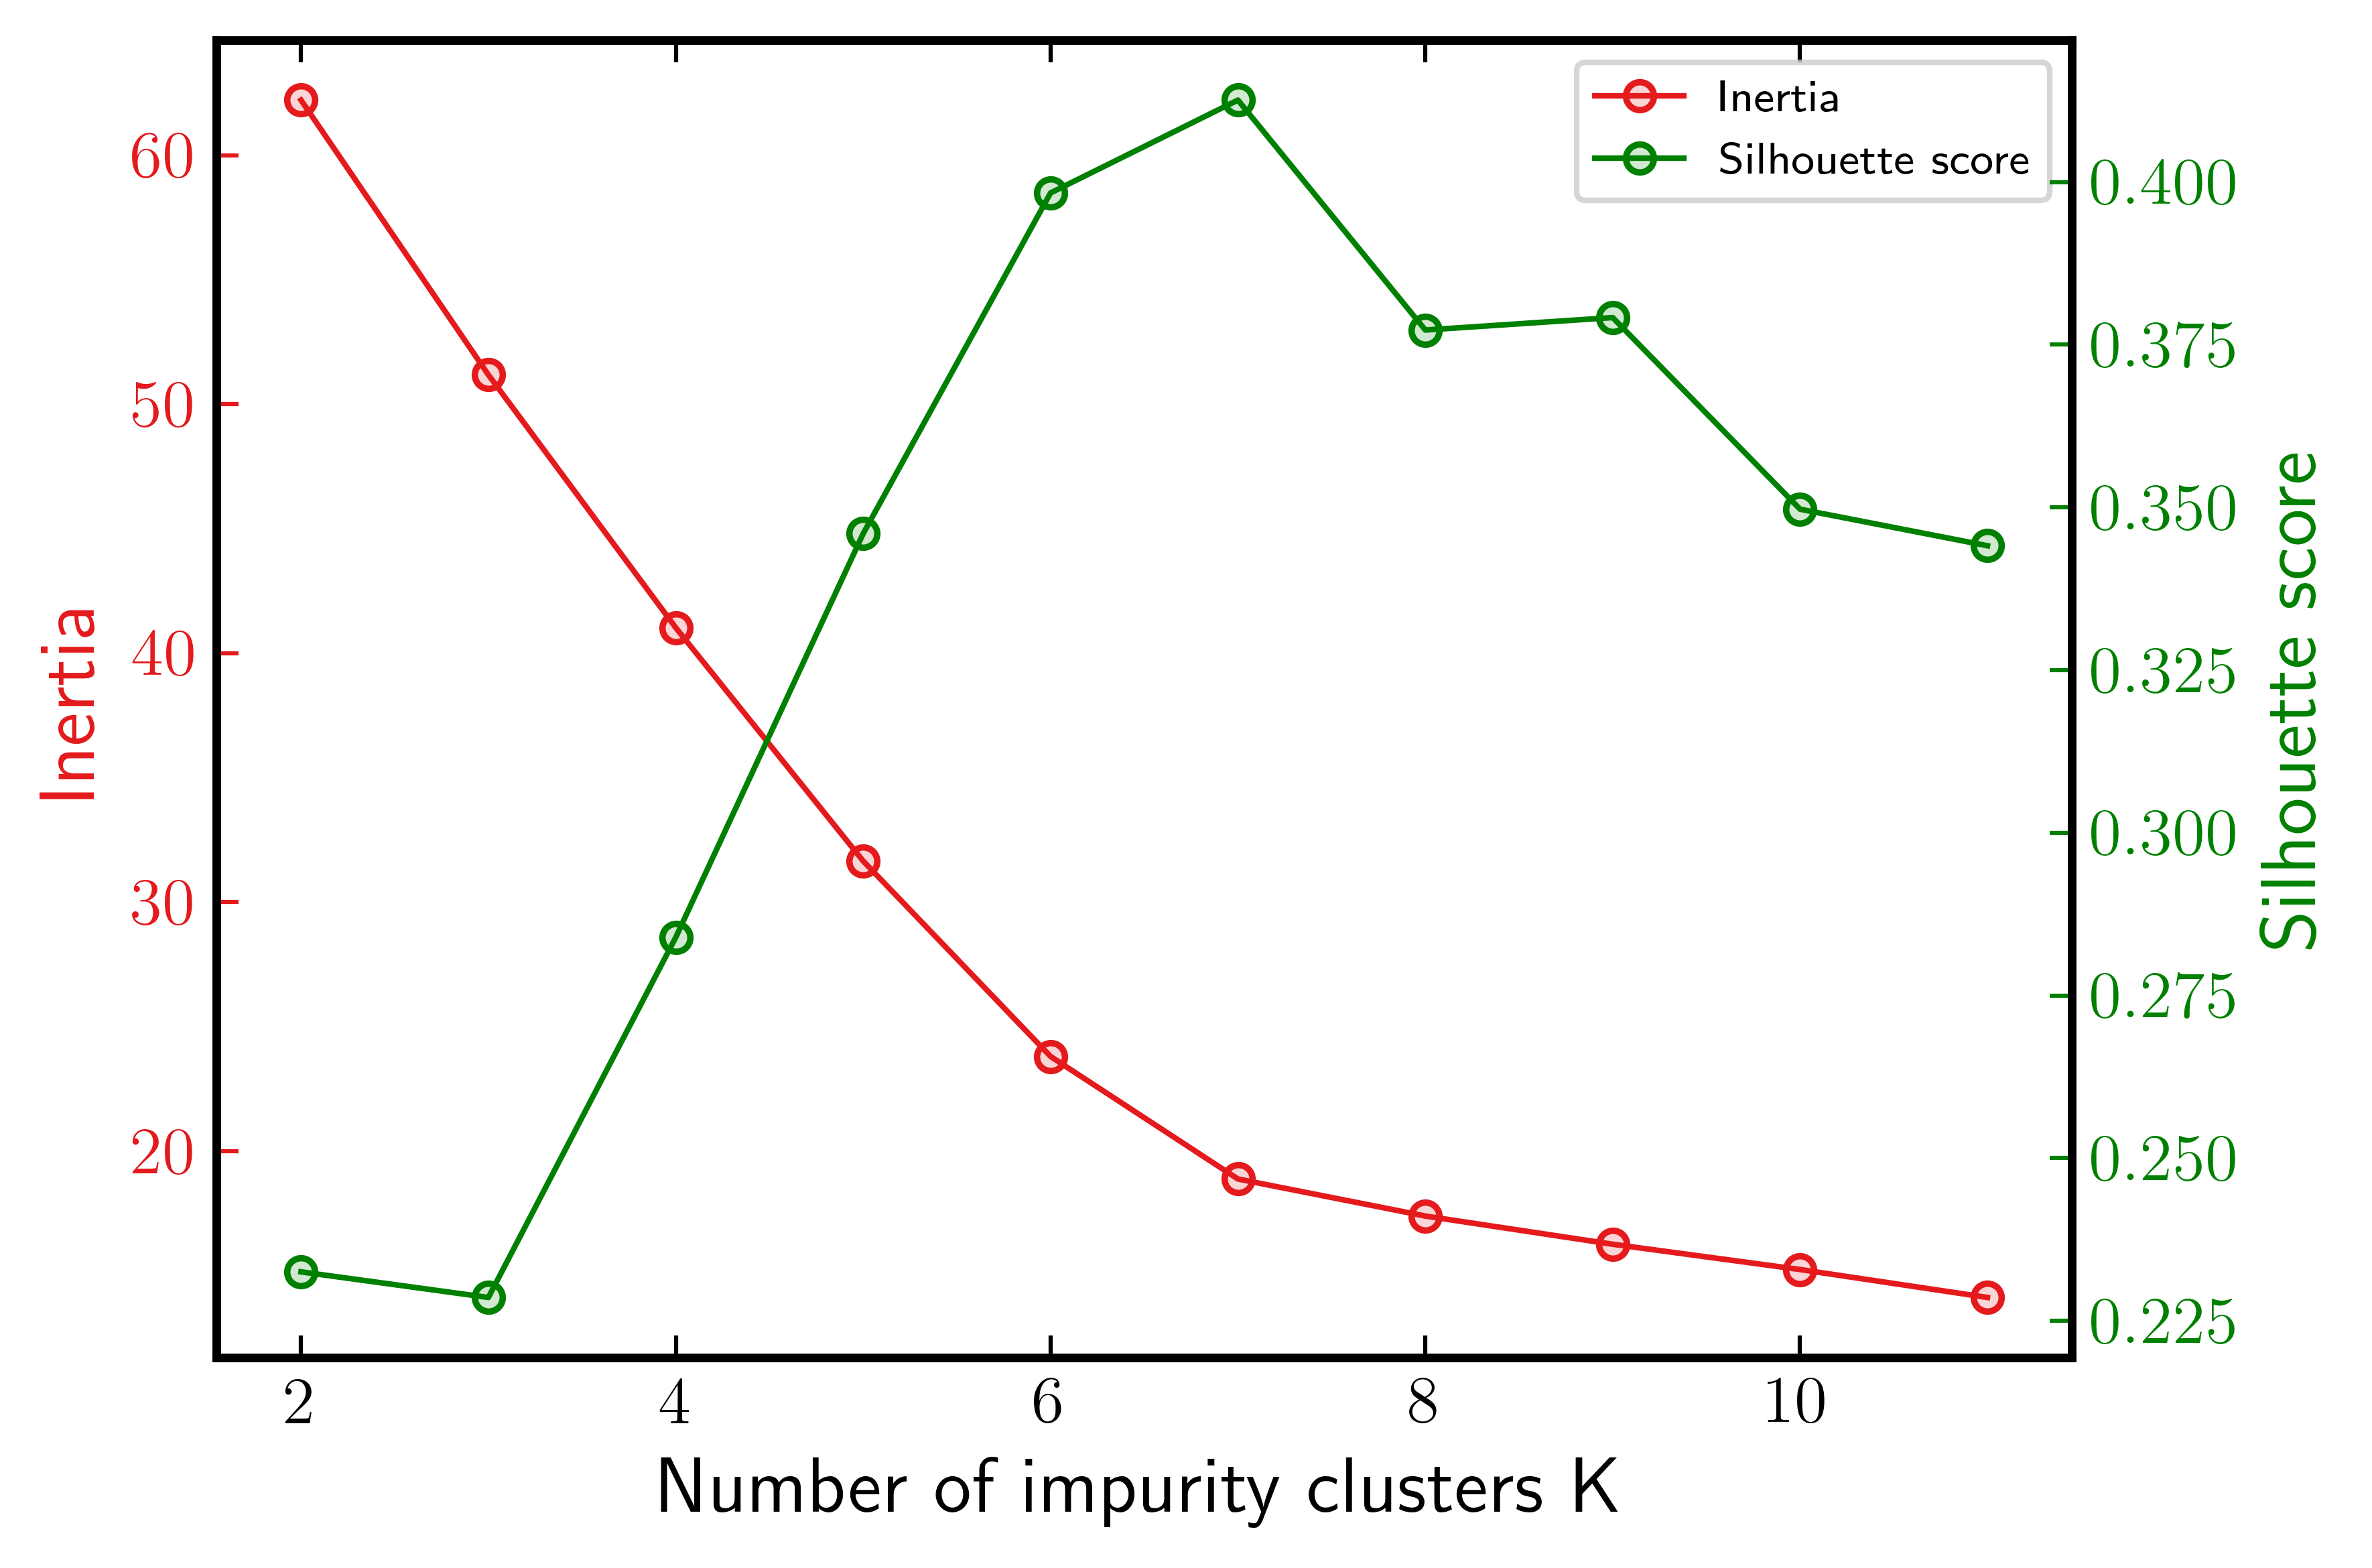

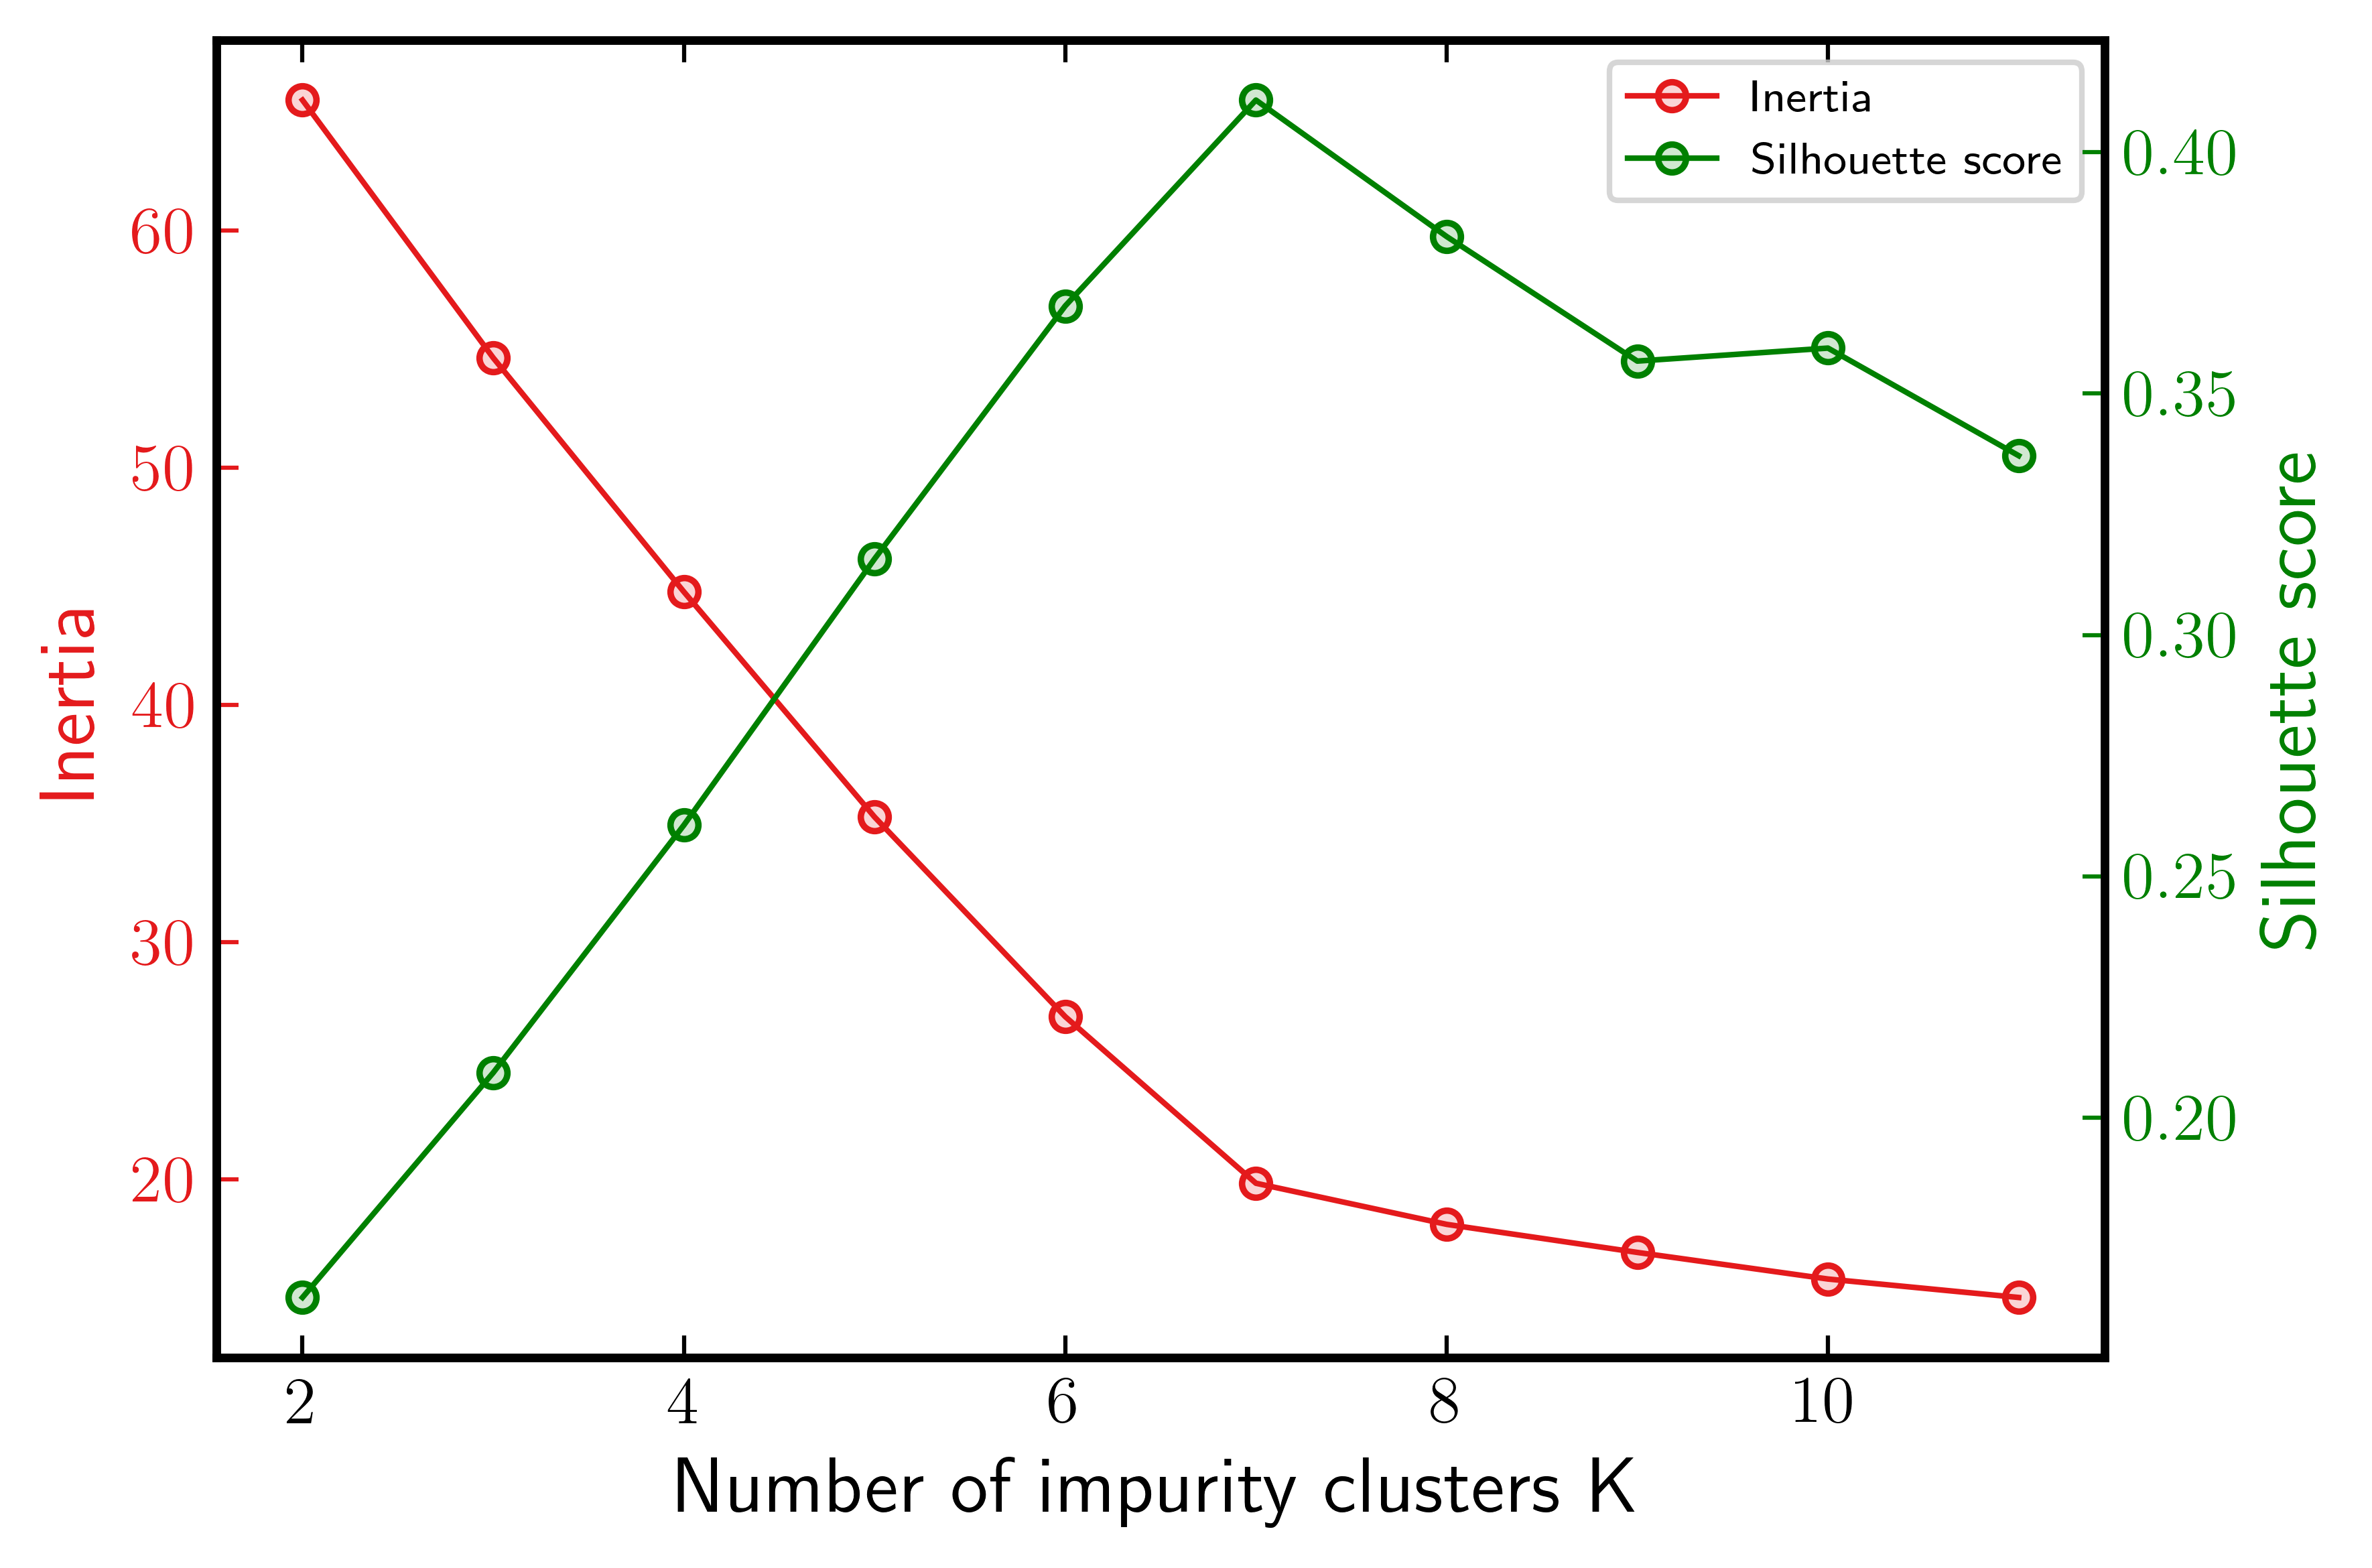

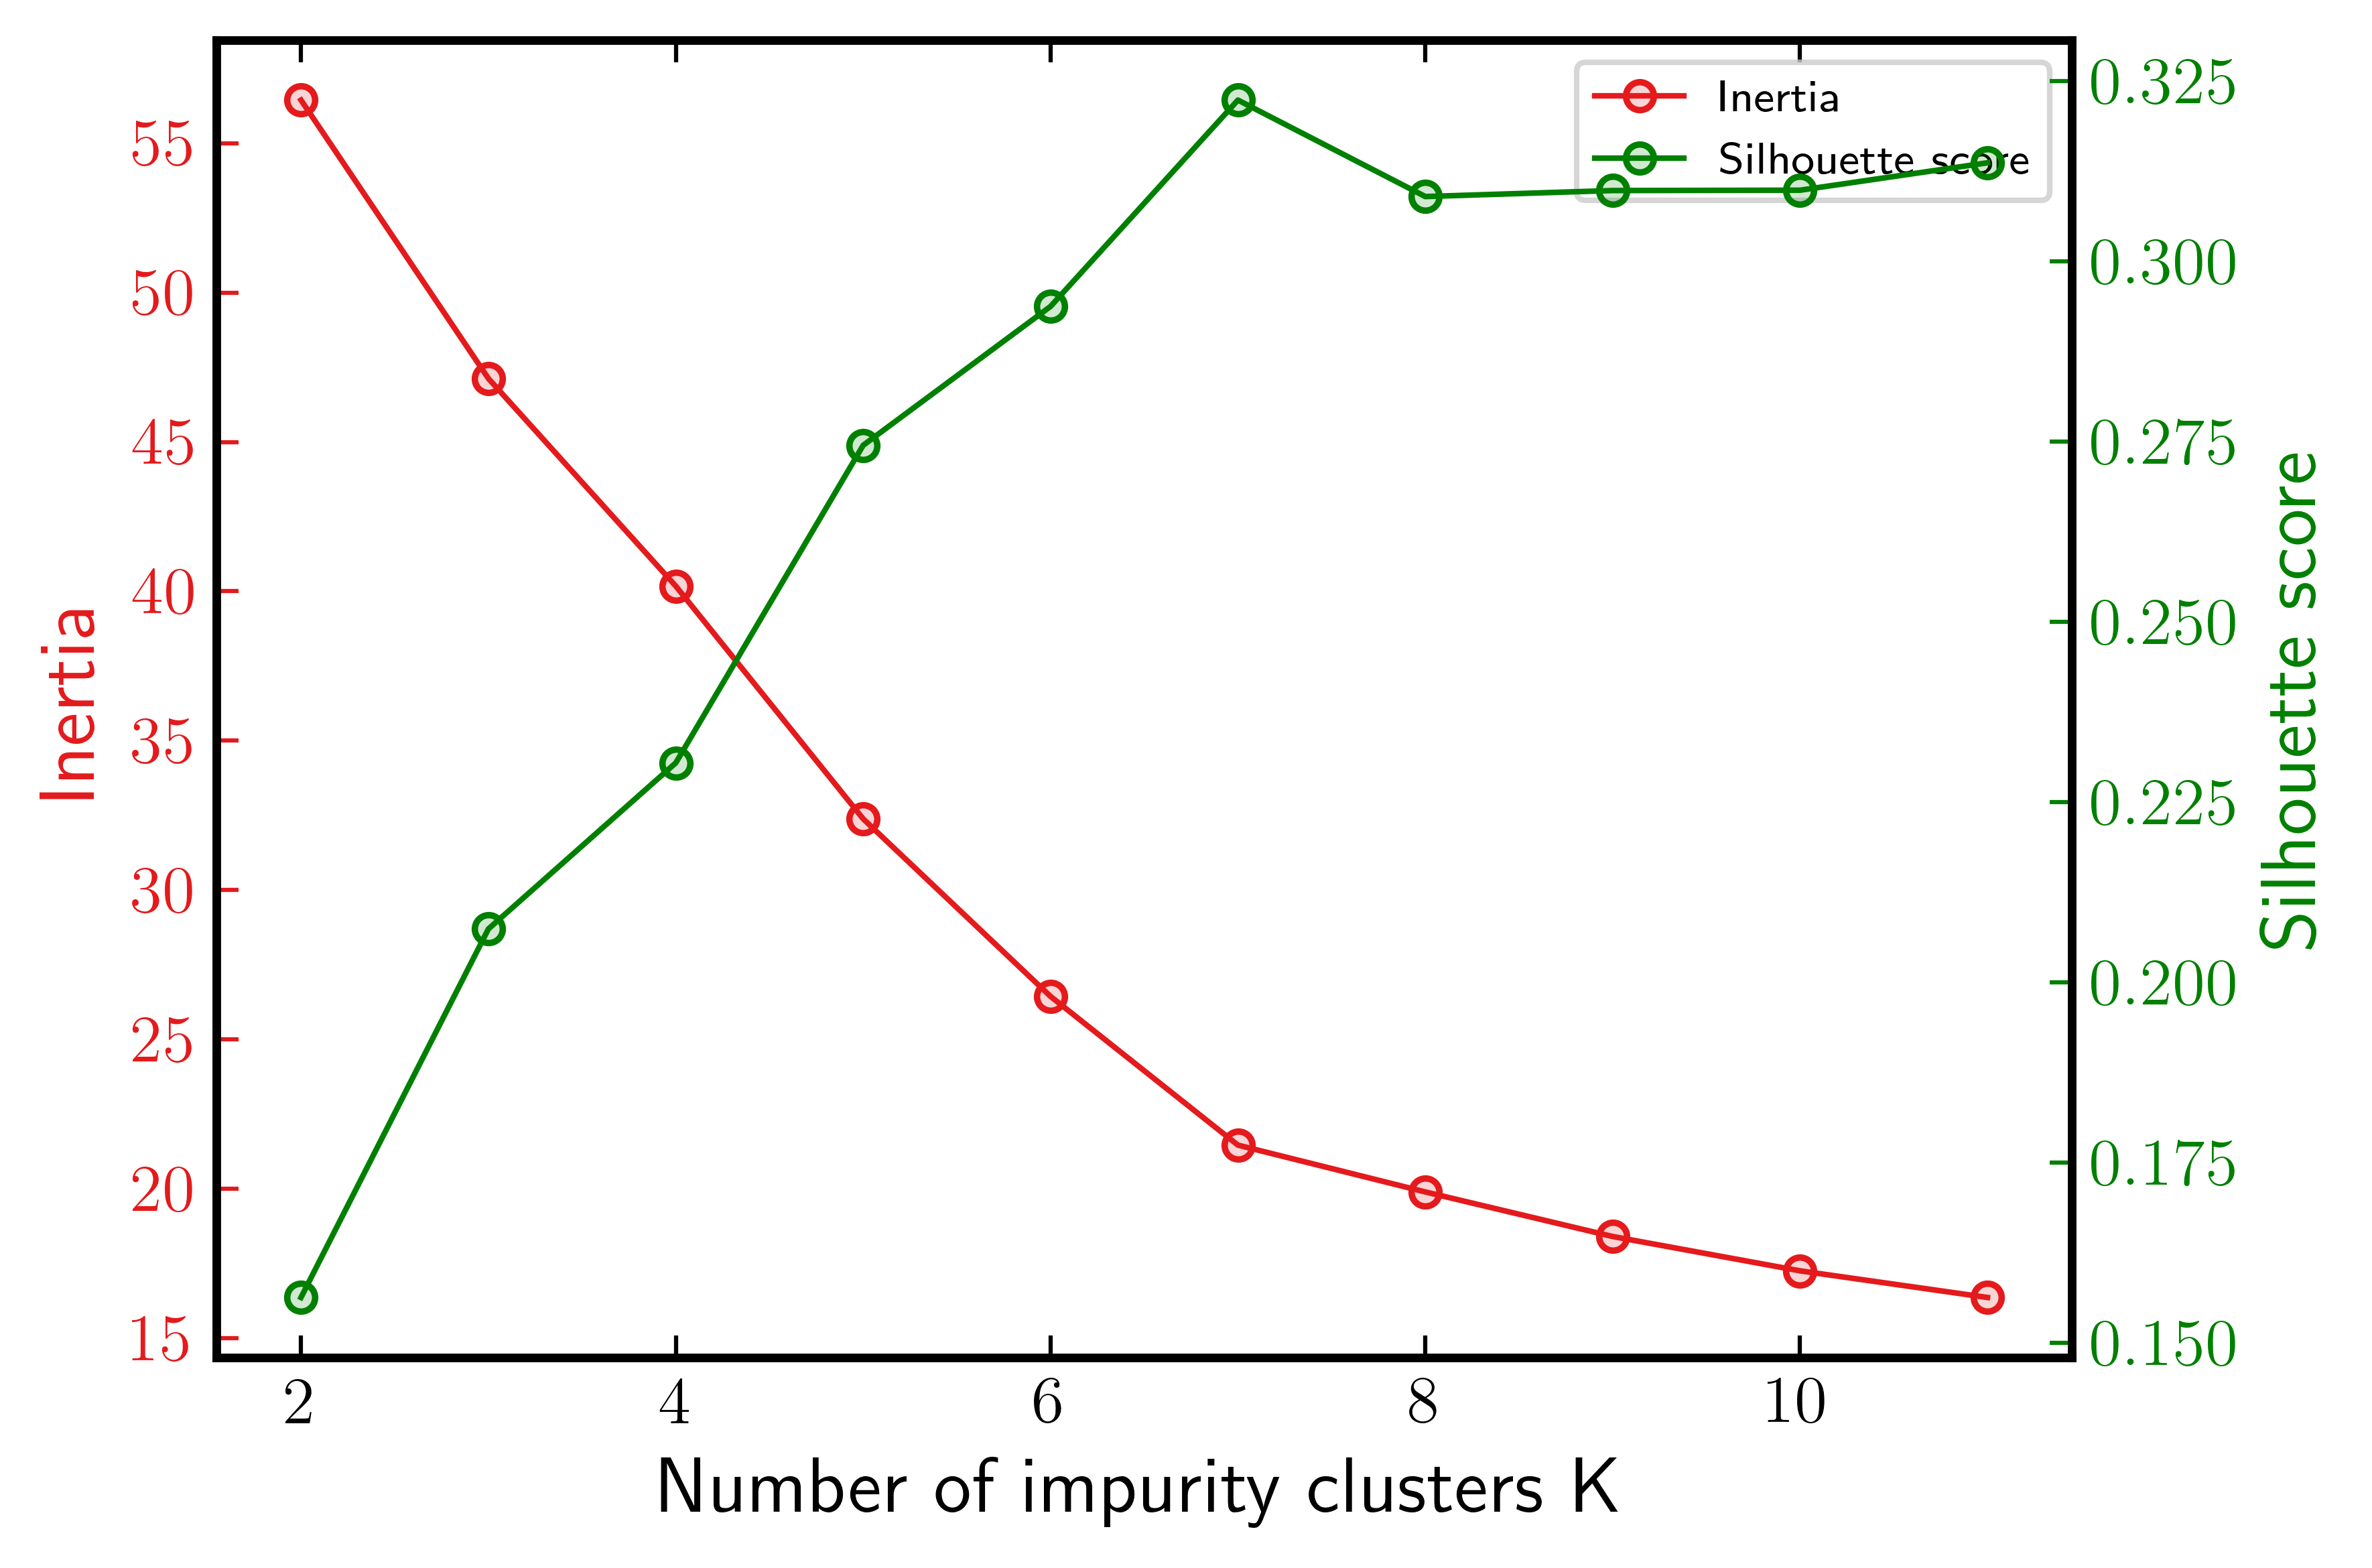

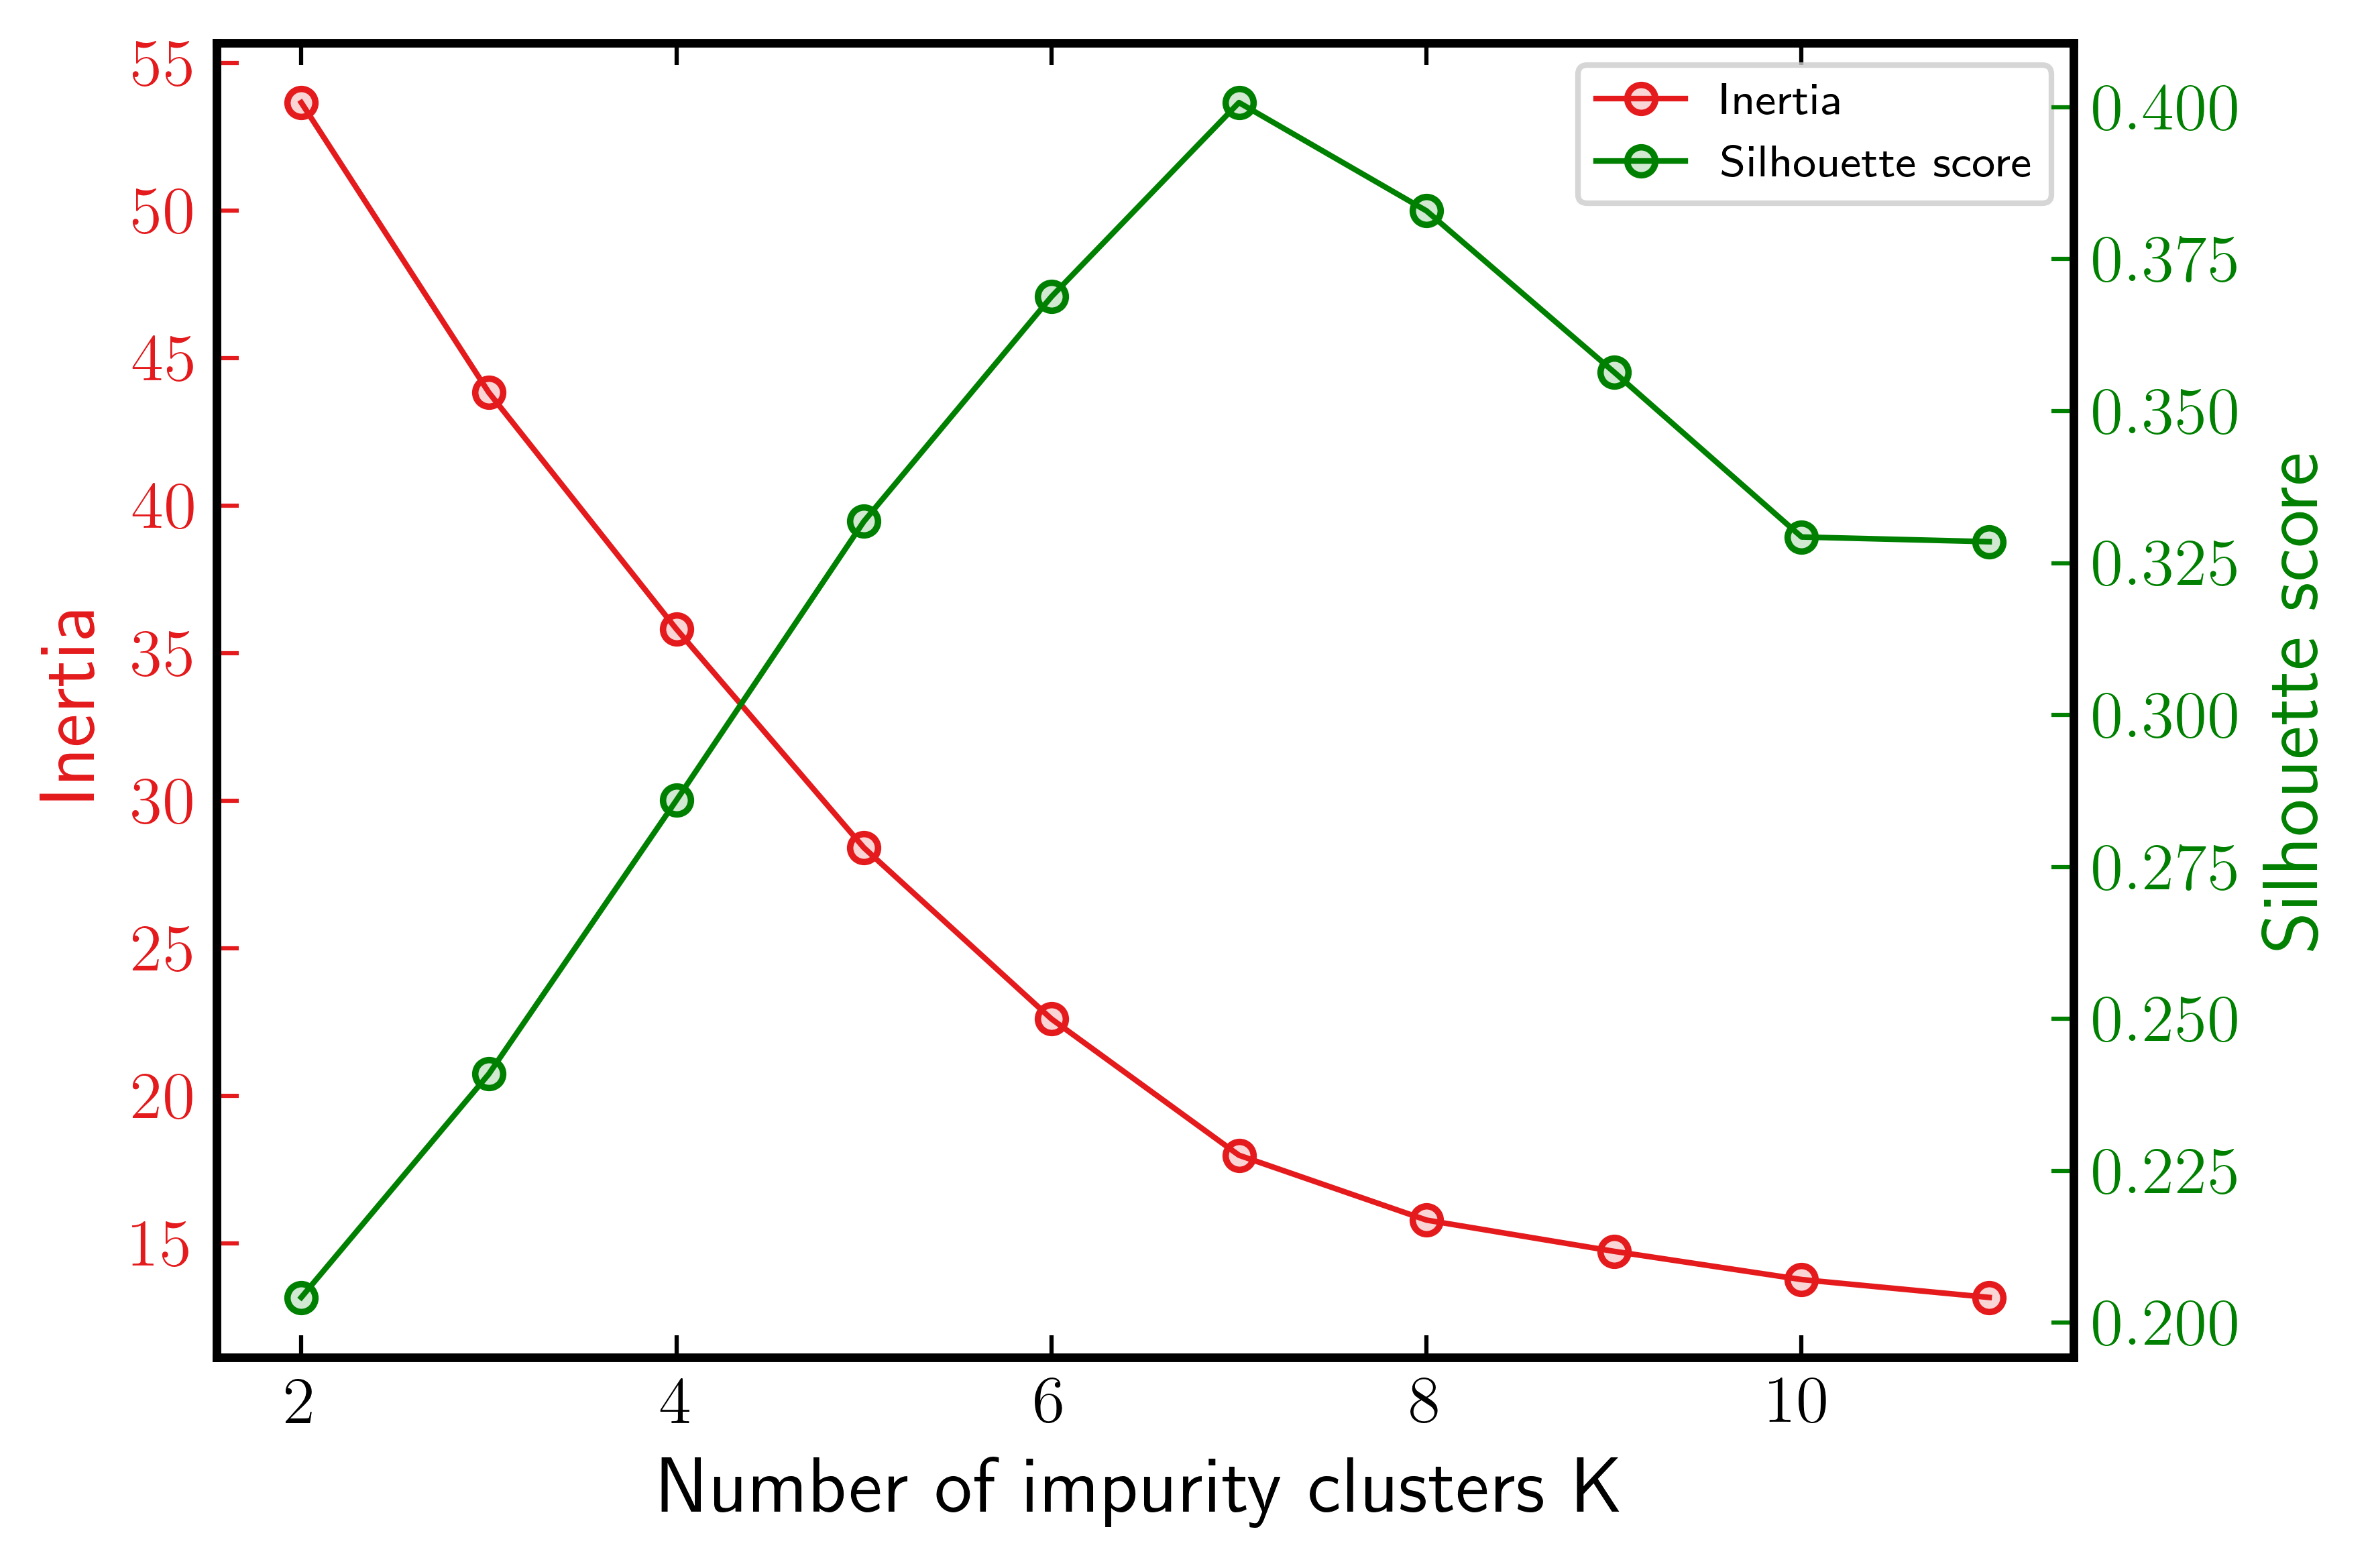

In [8]:
for b in CO2_LABELS:
    sub = k_diagnostics[k_diagnostics["co2_bin"] == b]

    if len(sub) == 0:
        continue

    fig, ax = ps.plot_init(w=6, h=4)
    ax2 = ax.twinx()
    inertia_color = ps.colors[0]
    silhouette_color = ps.colors[1]
    inertia_facecolor = (*ps.mcolors.to_rgb(inertia_color), DIAGNOSTIC_MARKERFACE_ALPHA)
    silhouette_facecolor = (*ps.mcolors.to_rgb(silhouette_color), DIAGNOSTIC_MARKERFACE_ALPHA)

    ax.plot(
        sub["K"],
        sub["inertia"],
        color=inertia_color,
        marker=ps.markers[0],
        markersize=DIAGNOSTIC_MARKERSIZE,
        markerfacecolor=inertia_facecolor,
        markeredgecolor=inertia_color,
        markeredgewidth=DIAGNOSTIC_MARKEREDGEWIDTH,
        linewidth=ps.linewidth,
        label="Inertia",
    )
    ax2.plot(
        sub["K"],
        sub["silhouette"],
        color=silhouette_color,
        marker=ps.markers[0],
        markersize=DIAGNOSTIC_MARKERSIZE,
        markerfacecolor=silhouette_facecolor,
        markeredgecolor=silhouette_color,
        markeredgewidth=DIAGNOSTIC_MARKEREDGEWIDTH,
        linewidth=ps.linewidth,
        label="Silhouette score",
    )

    ax.set_xlabel("Number of impurity clusters K", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_ylabel("Inertia", fontsize=PLOT_LABEL_FONTSIZE, color=inertia_color)
    ax2.set_ylabel("Silhouette score", fontsize=PLOT_LABEL_FONTSIZE, color=silhouette_color)

    ps.apply_axis_style(ax)
    ps.apply_axis_style(ax2)
    ax.tick_params(
        axis="y", which="both", colors=inertia_color,
        left=True, right=False, labelleft=True, labelright=False,
        labelsize=PLOT_TICK_LABELSIZE,
    )
    ax2.tick_params(
        axis="y", which="both", colors=silhouette_color,
        left=False, right=True, labelleft=False, labelright=True,
        labelsize=PLOT_TICK_LABELSIZE,
    )
    ax.tick_params(axis="x", which="both", labelsize=PLOT_TICK_LABELSIZE)
    ax2.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False, labeltop=False)

    lines = ax.get_lines() + ax2.get_lines()
    labels = [line.get_label() for line in lines]
    ax.legend(lines, labels, fontsize=PLOT_LEGEND_FONTSIZE, loc="best")

    fig.tight_layout()
    plt.show()

In [9]:
# Elbow and silhouette diagnostics are plotted together in the previous cell.

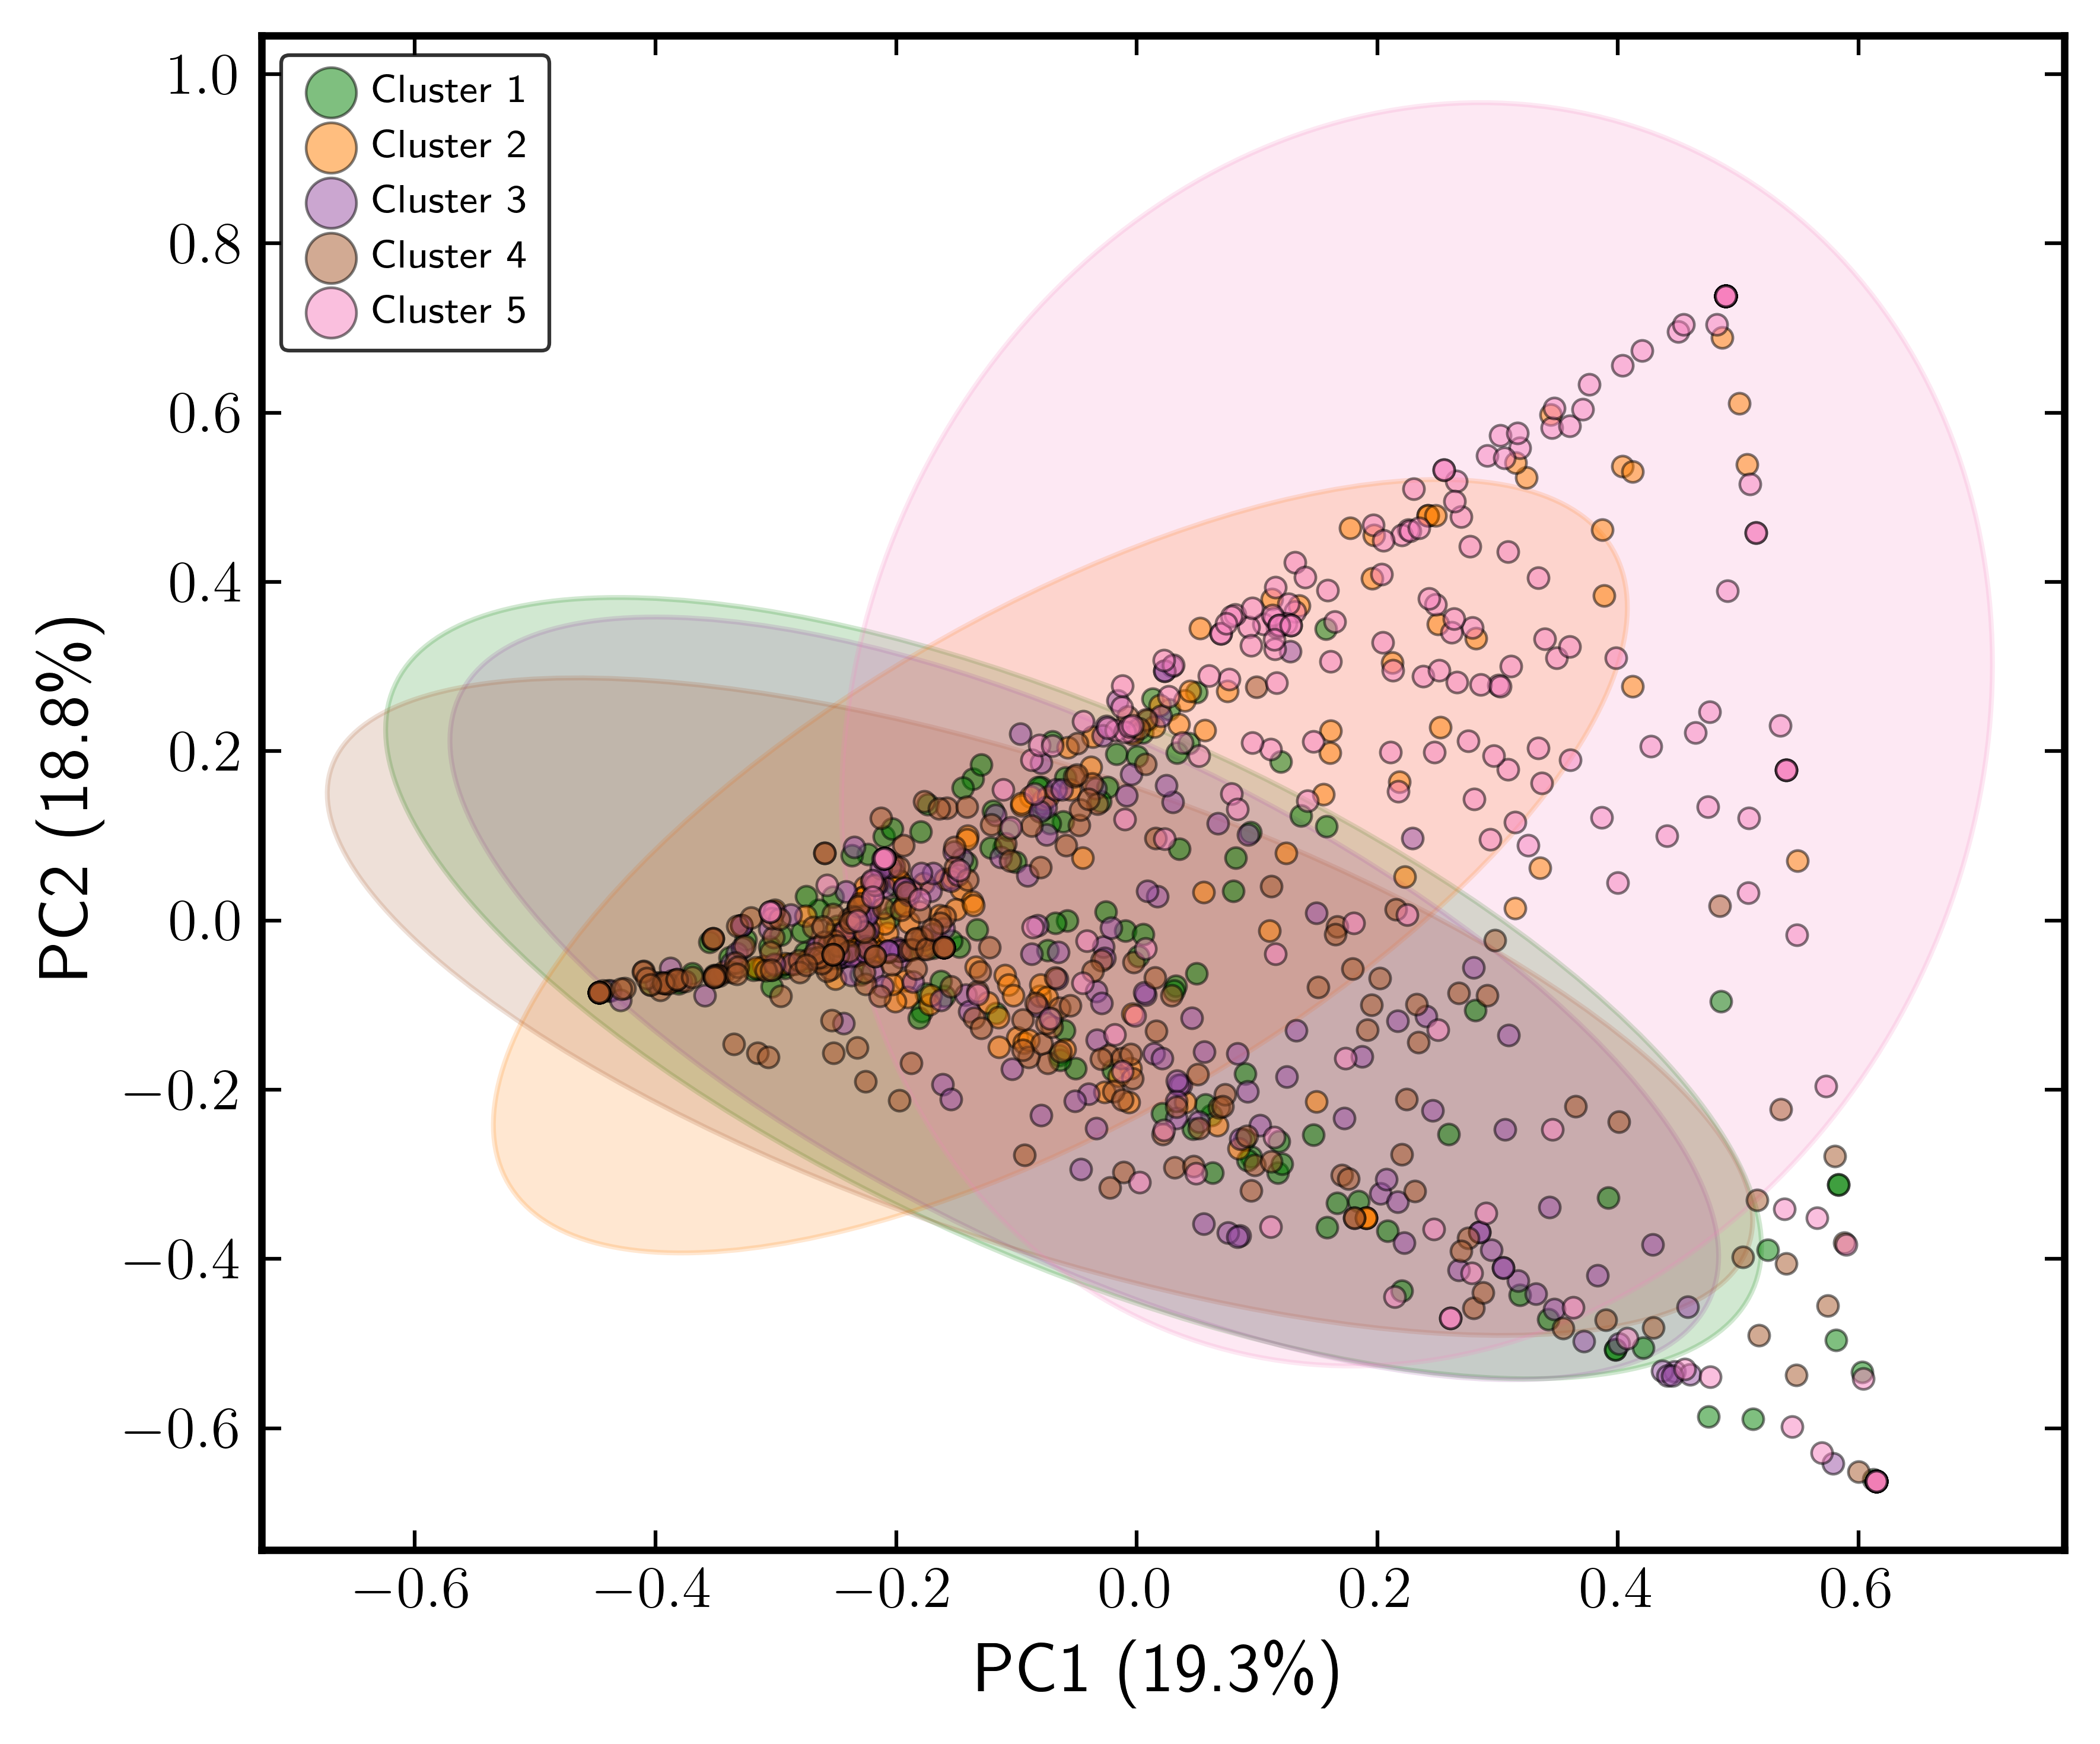

In [10]:
# ── Plot: k-means clusters via PCA projection (global scaler for viz only) ─────
X_imp_all  = pool[IMPURITY_COLS].values
x_tot_all  = (1.0 - pool["CO2"].values).reshape(-1, 1)
X_norm_all = X_imp_all / np.clip(x_tot_all, 1e-12, None)

scaler_global = MinMaxScaler()
X_scaled_all  = scaler_global.fit_transform(X_norm_all)

pca   = PCA(n_components=2, random_state=BASE_SEED)
X_pca = pca.fit_transform(X_scaled_all)

from matplotlib.patches import Ellipse

def add_cluster_background(ax, pts, color, n_std=2.2):
    if len(pts) < 2:
        return

    center = pts.mean(axis=0)
    cov = np.cov(pts, rowvar=False)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(np.maximum(vals, 1e-12))

    # Keep tight clusters visible, including the small top cluster.
    width = max(width, 0.35)
    height = max(height, 0.25)

    ellipse = Ellipse(
        xy=center,
        width=width,
        height=height,
        angle=angle,
        facecolor=color,
        edgecolor=color,
        alpha=0.18,
        linewidth=1.0,
        zorder=1,
    )
    ax.add_patch(ellipse)

fig, ax = ps.plot_init(w=6, h=5)
cluster_colors = ps.color_10
for i, c in enumerate(sorted(pool["imp_cluster"].unique())):
    mask = pool["imp_cluster"] == c
    pts = X_pca[mask]
    color = cluster_colors[i % len(cluster_colors)]
    add_cluster_background(ax, pts, color)
    ax.scatter(
        pts[:, 0],
        pts[:, 1],
        s=18,
        alpha=ps.alpha,
        color=color,
        edgecolor="black",
        linewidth=0.55,
        label=f"Cluster {c + 1}",
        zorder=2,
    )
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}" + r"\%)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}" + r"\%)", fontsize=PLOT_LABEL_FONTSIZE)
ps.style_legend(ax, loc="upper left", markerscale=2.4, fontsize=PLOT_LEGEND_FONTSIZE)
fig.tight_layout()
plt.show()

In [11]:
# ── Stratum = CO_2_bin × imp_cluster ──────────────────────────────────────────
pool["stratum"] = pool["co2_bin"].astype(str) + "__c" + pool["imp_cluster"].astype(str)

stratum_counts = pool["stratum"].value_counts().sort_index()
print(f"Total strata: {len(stratum_counts)}")
print(stratum_counts.to_string())

Total strata: 25
stratum
0.95-0.96__c0    42
0.95-0.96__c1    41
0.95-0.96__c2    44
0.95-0.96__c3    55
0.95-0.96__c4    63
0.96-0.97__c0    27
0.96-0.97__c1    25
0.96-0.97__c2    62
0.96-0.97__c3    33
0.96-0.97__c4    44
0.97-0.98__c0    40
0.97-0.98__c1    39
0.97-0.98__c2    26
0.97-0.98__c3    66
0.97-0.98__c4    28
0.98-0.99__c0    38
0.98-0.99__c1    22
0.98-0.99__c2    28
0.98-0.99__c3    59
0.98-0.99__c4    36
0.99-1.00__c0    33
0.99-1.00__c1    48
0.99-1.00__c2    36
0.99-1.00__c3    28
0.99-1.00__c4    37


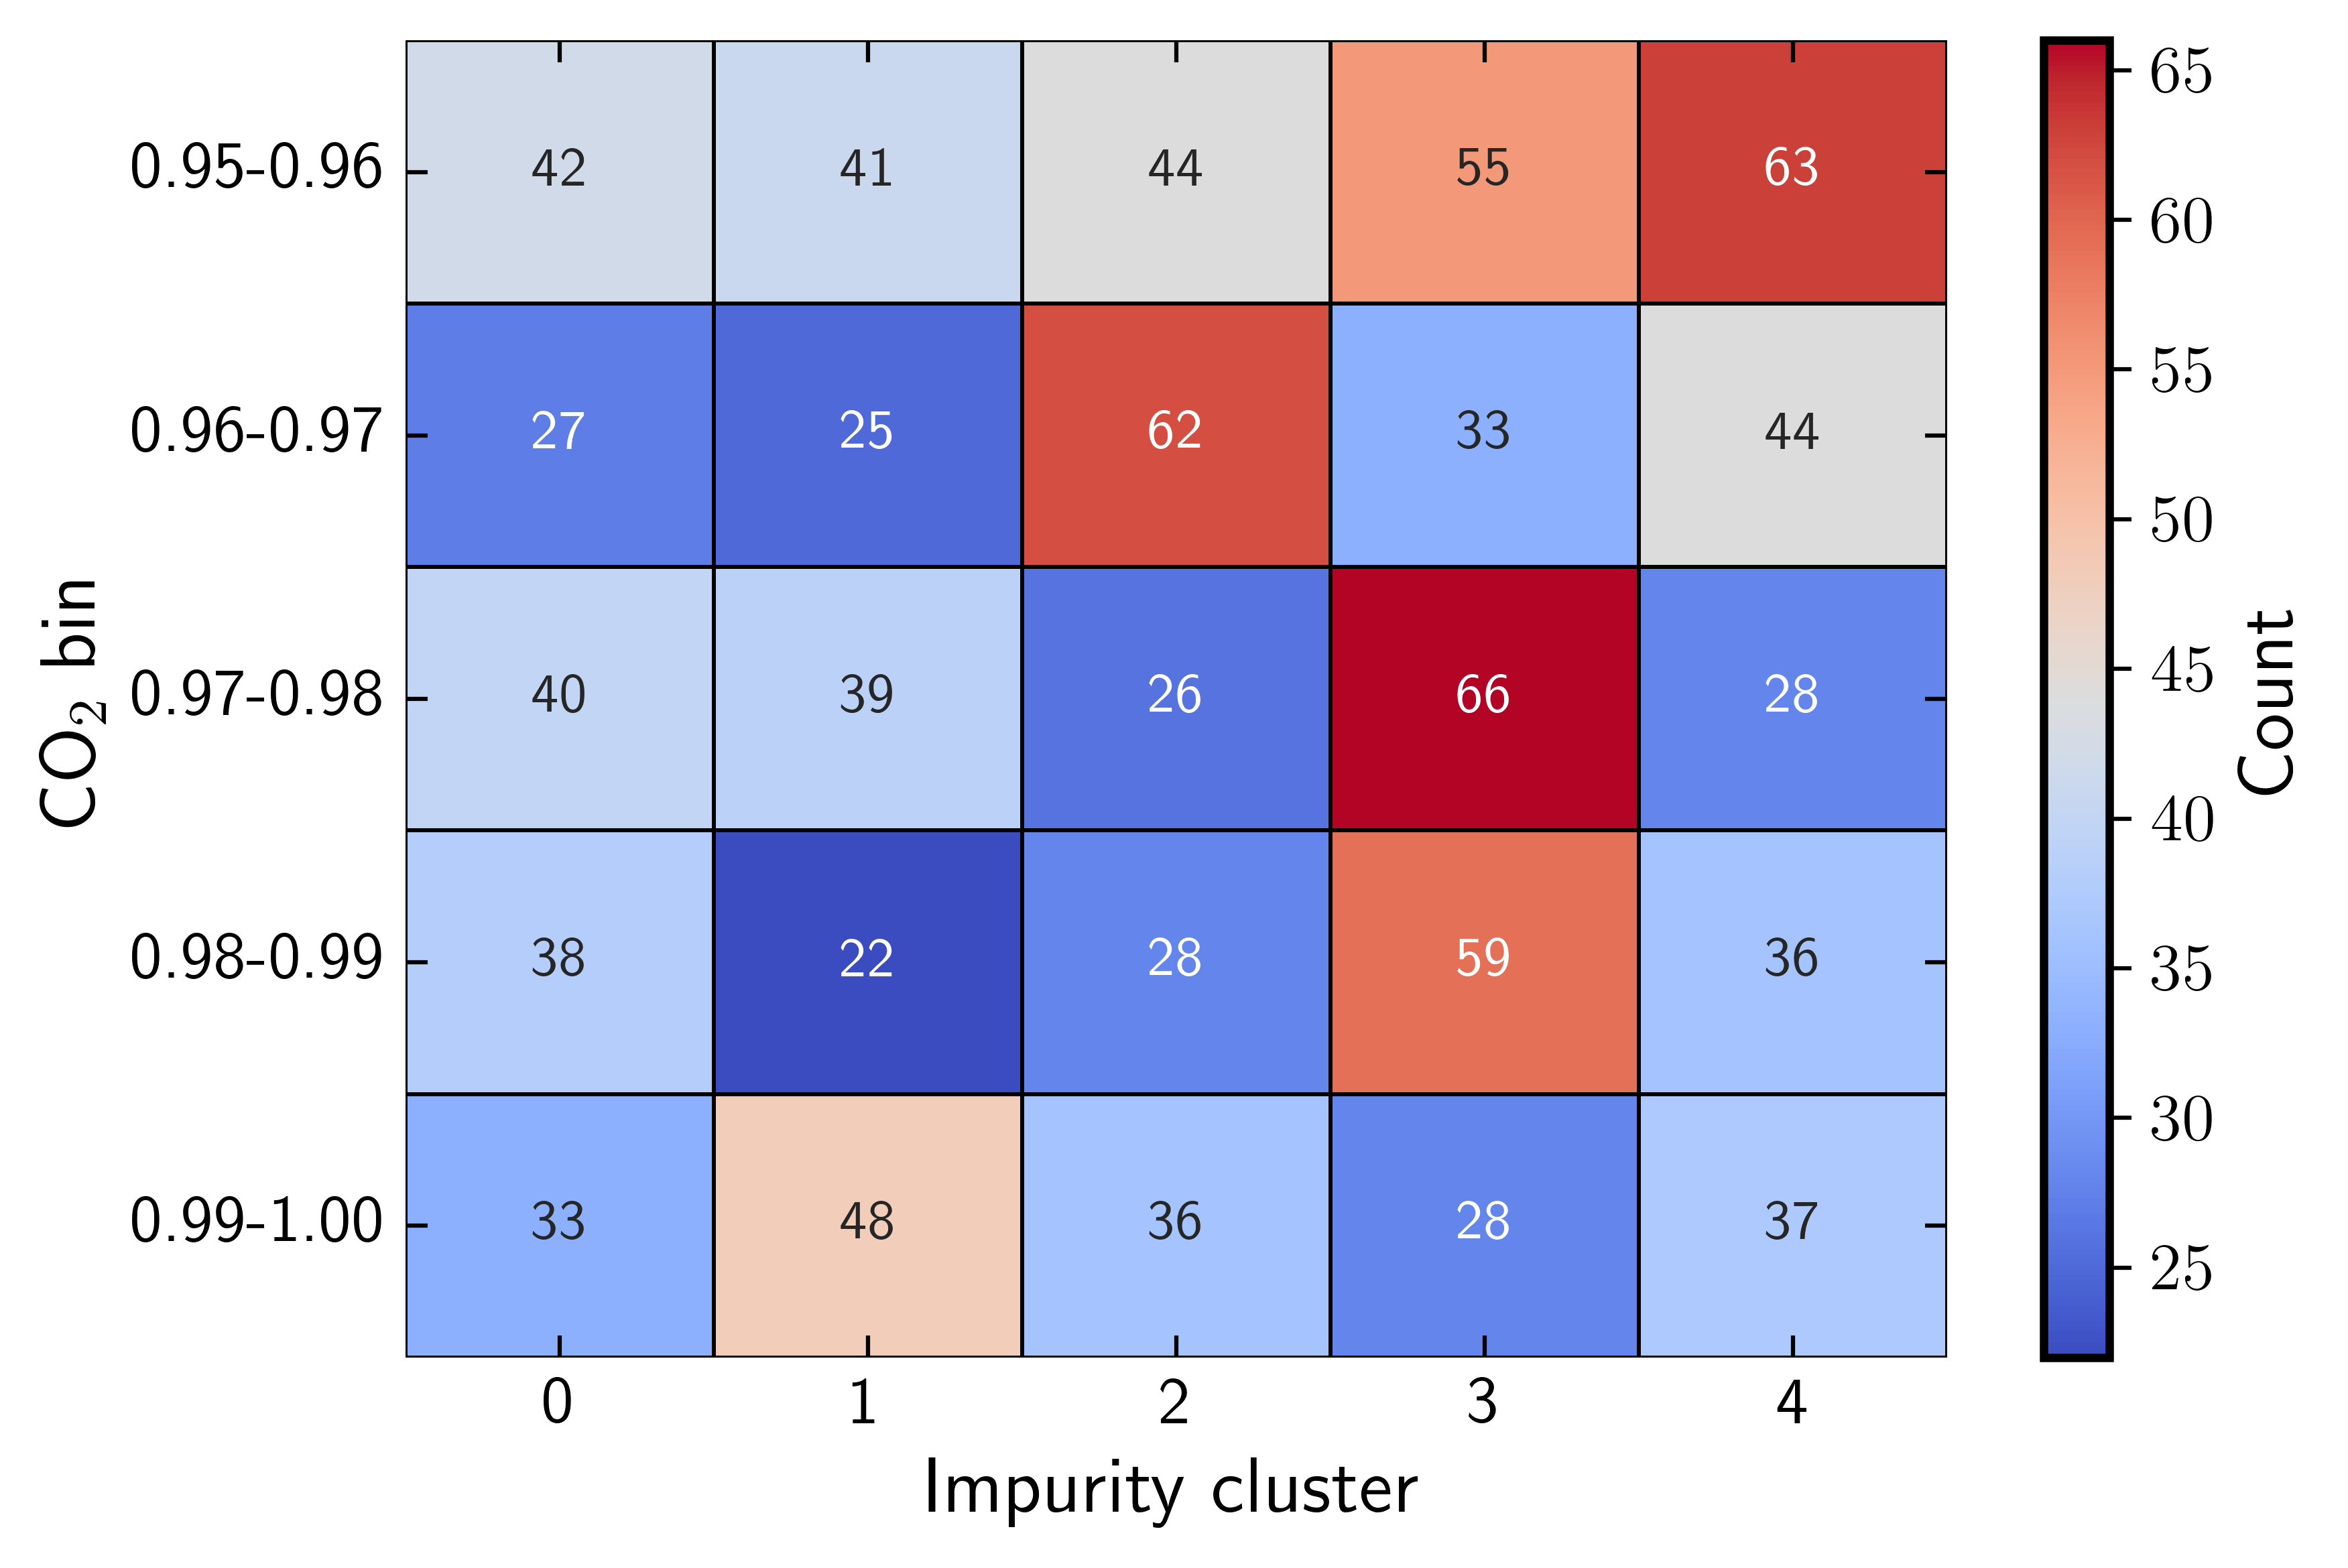

In [12]:
# ── Plot: stratum heatmap (CO_2 bin × impurity cluster) ───────────────────────
pivot = pool.groupby(["co2_bin", "imp_cluster"], observed=True).size().unstack(fill_value=0)

fig, ax = ps.plot_init(w=6, h=4)
heatmap = sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap=ps.map,
    linewidths=0.5,
    linecolor="black",
    cbar_kws={"label": "Count"},
    ax=ax,
)
ax.set_xlabel("Impurity cluster", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel(r"CO$_2$ bin", fontsize=PLOT_LABEL_FONTSIZE)
ps.apply_axis_style(ax)
if heatmap.collections and heatmap.collections[0].colorbar is not None:
    cbar = heatmap.collections[0].colorbar
    cbar.ax.set_ylabel("Count", fontsize=PLOT_LABEL_FONTSIZE)
    ps.style_colorbar(cbar)
fig.tight_layout()
plt.show()

In [13]:
# ── Proportional allocation helper ────────────────────────────────────────────
def proportional_allocate(counts: pd.Series, N: int) -> pd.Series:
    """Proportional allocation across strata, adjusted to sum exactly to N."""
    alloc = (counts / counts.sum() * N).round().clip(lower=1).astype(int)
    # Adjust so alloc.sum() == N
    while alloc.sum() > N:
        alloc[alloc.idxmax()] -= 1
    while alloc.sum() < N:
        alloc[alloc.idxmin()] += 1
    return alloc

In [14]:
# ── Sample, build selections, save CSVs ───────────────────────────────────────
OUTPUT_DIR.mkdir(exist_ok=True)
for N in N_SIZES:
    (OUTPUT_DIR / f"N{N:03d}").mkdir(exist_ok=True)

# Group pool by stratum once
strata_groups = {s: grp.index.tolist() for s, grp in pool.groupby("stratum")}

for trial in range(N_TRIALS):
    rng = get_rng(seed=BASE_SEED + trial, rng_type=RNG_TYPE)
    for N in N_SIZES:
        alloc = proportional_allocate(stratum_counts, N)
        chosen = []
        for stratum, k in alloc.items():
            candidates = strata_groups.get(stratum, [])
            k_actual   = min(k, len(candidates))
            chosen.extend(rng.choice(candidates, size=k_actual, replace=False).tolist())
        chosen = sorted(chosen)
        df = pool.iloc[chosen].drop(columns=["CO2_round", "co2_bin", "imp_cluster", "stratum"]).copy().reset_index(drop=True)
        df.insert(0, "pool_idx", chosen)
        df.to_csv(OUTPUT_DIR / f"N{N:03d}" / f"trial_{trial:02d}.csv", index=False)

print(f"Done — {N_TRIALS * len(N_SIZES)} CSV files saved")

Done — 80 CSV files saved


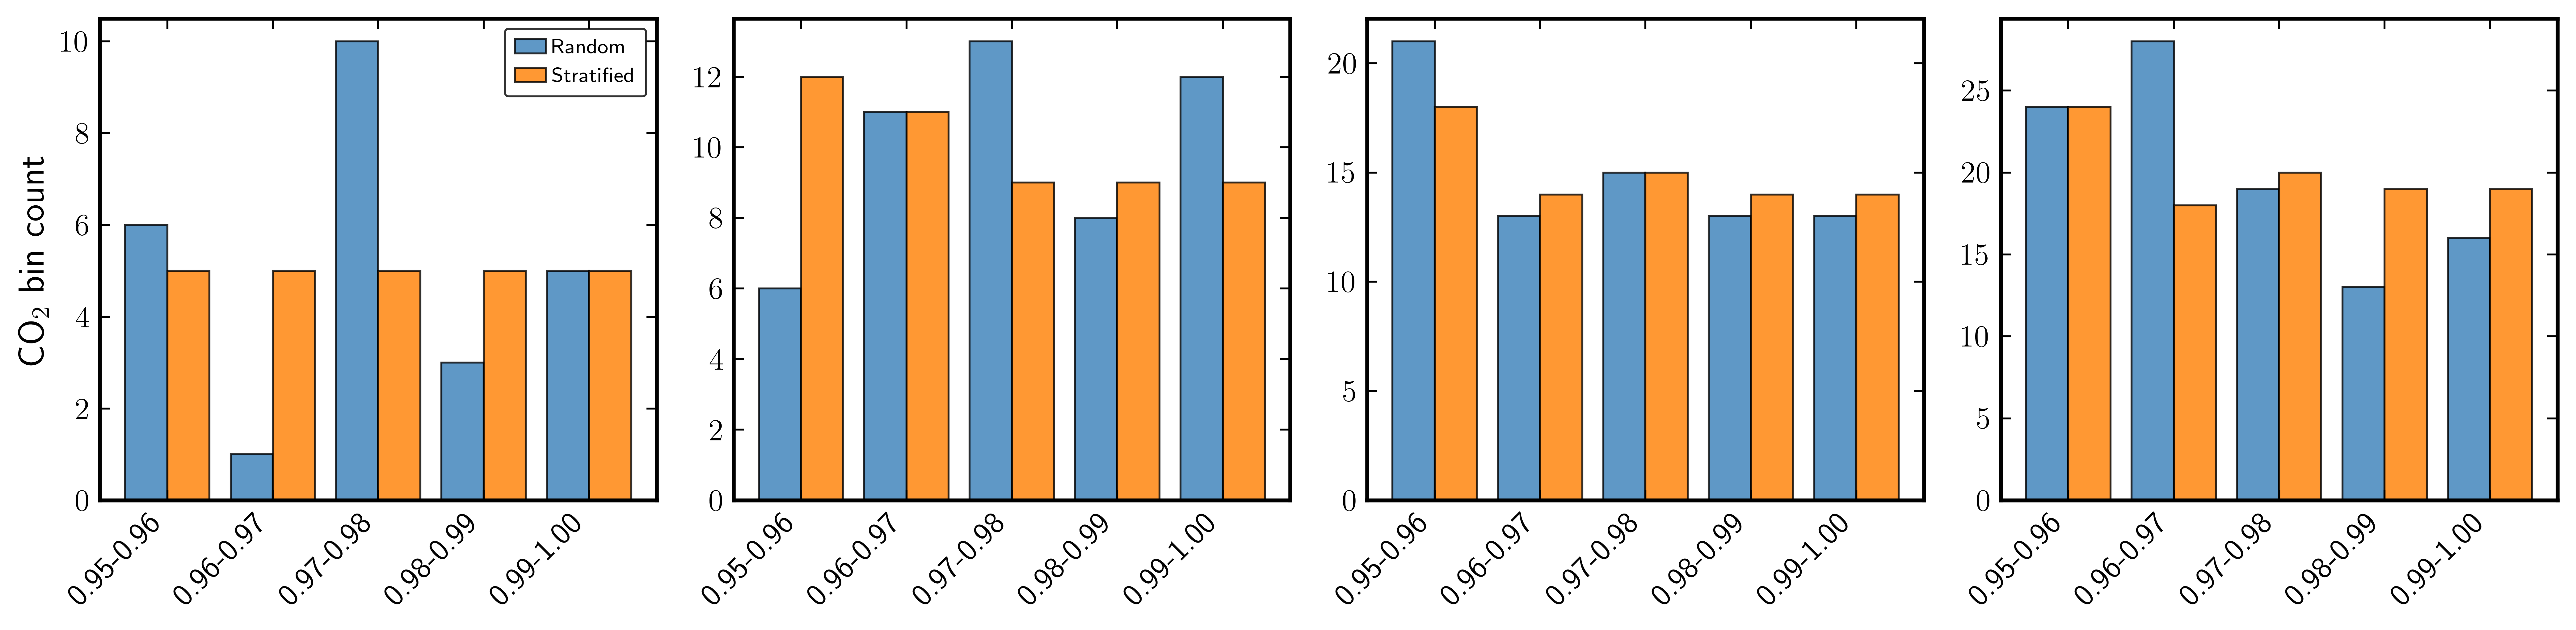

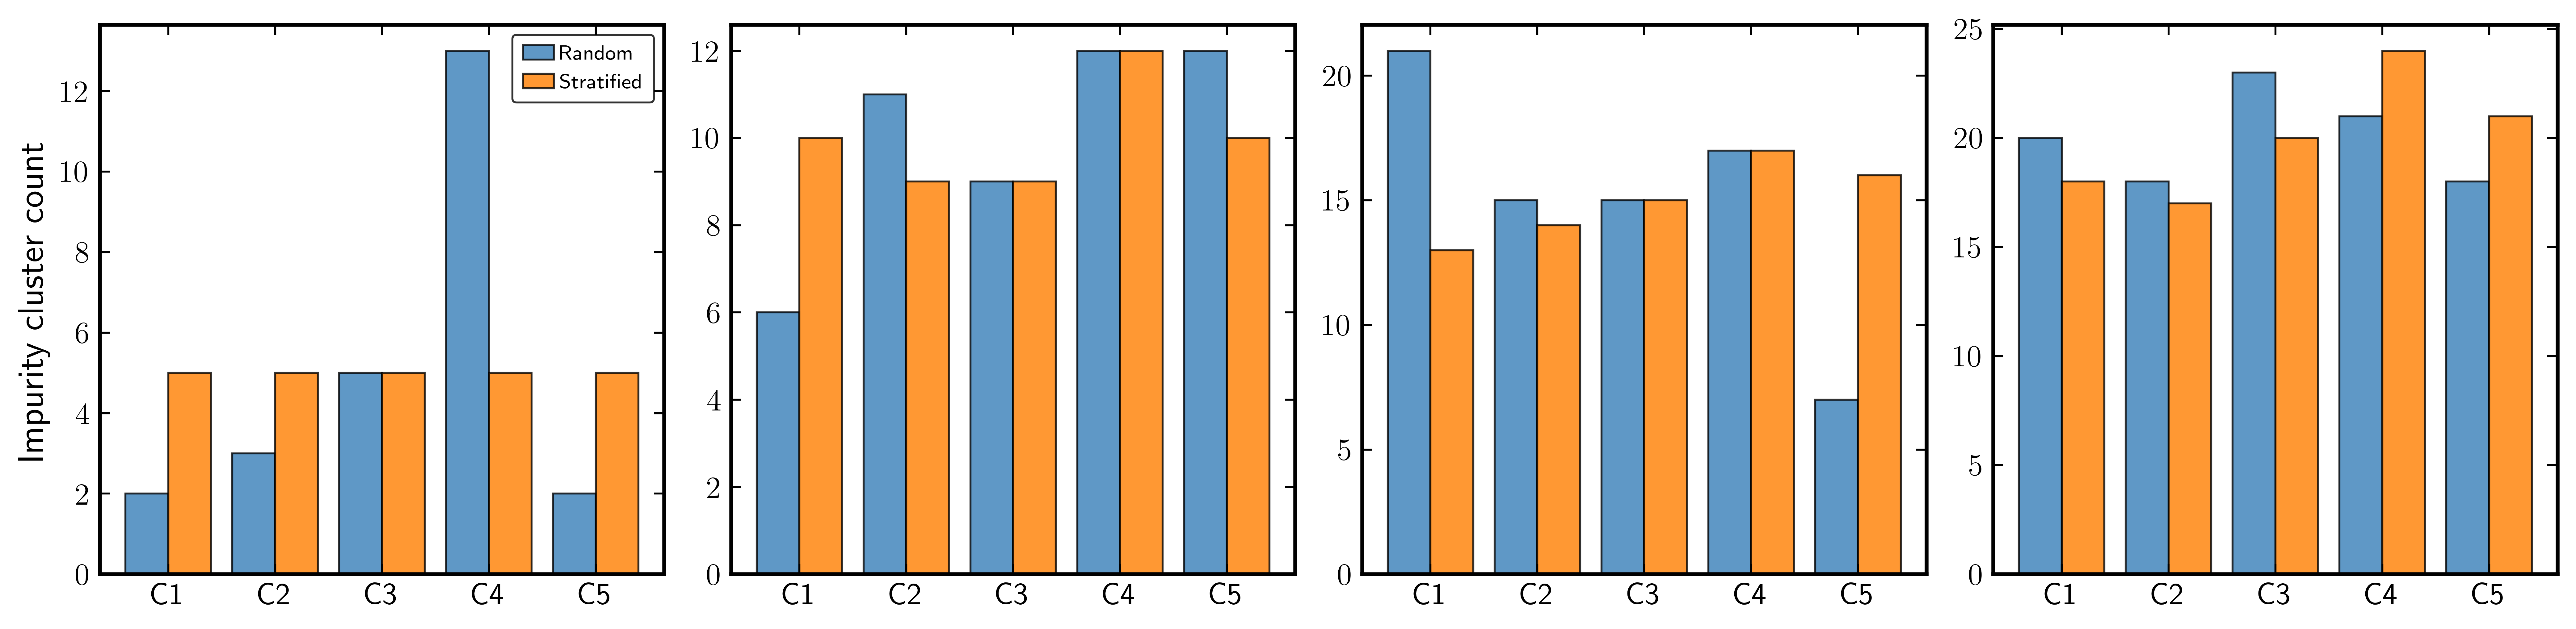

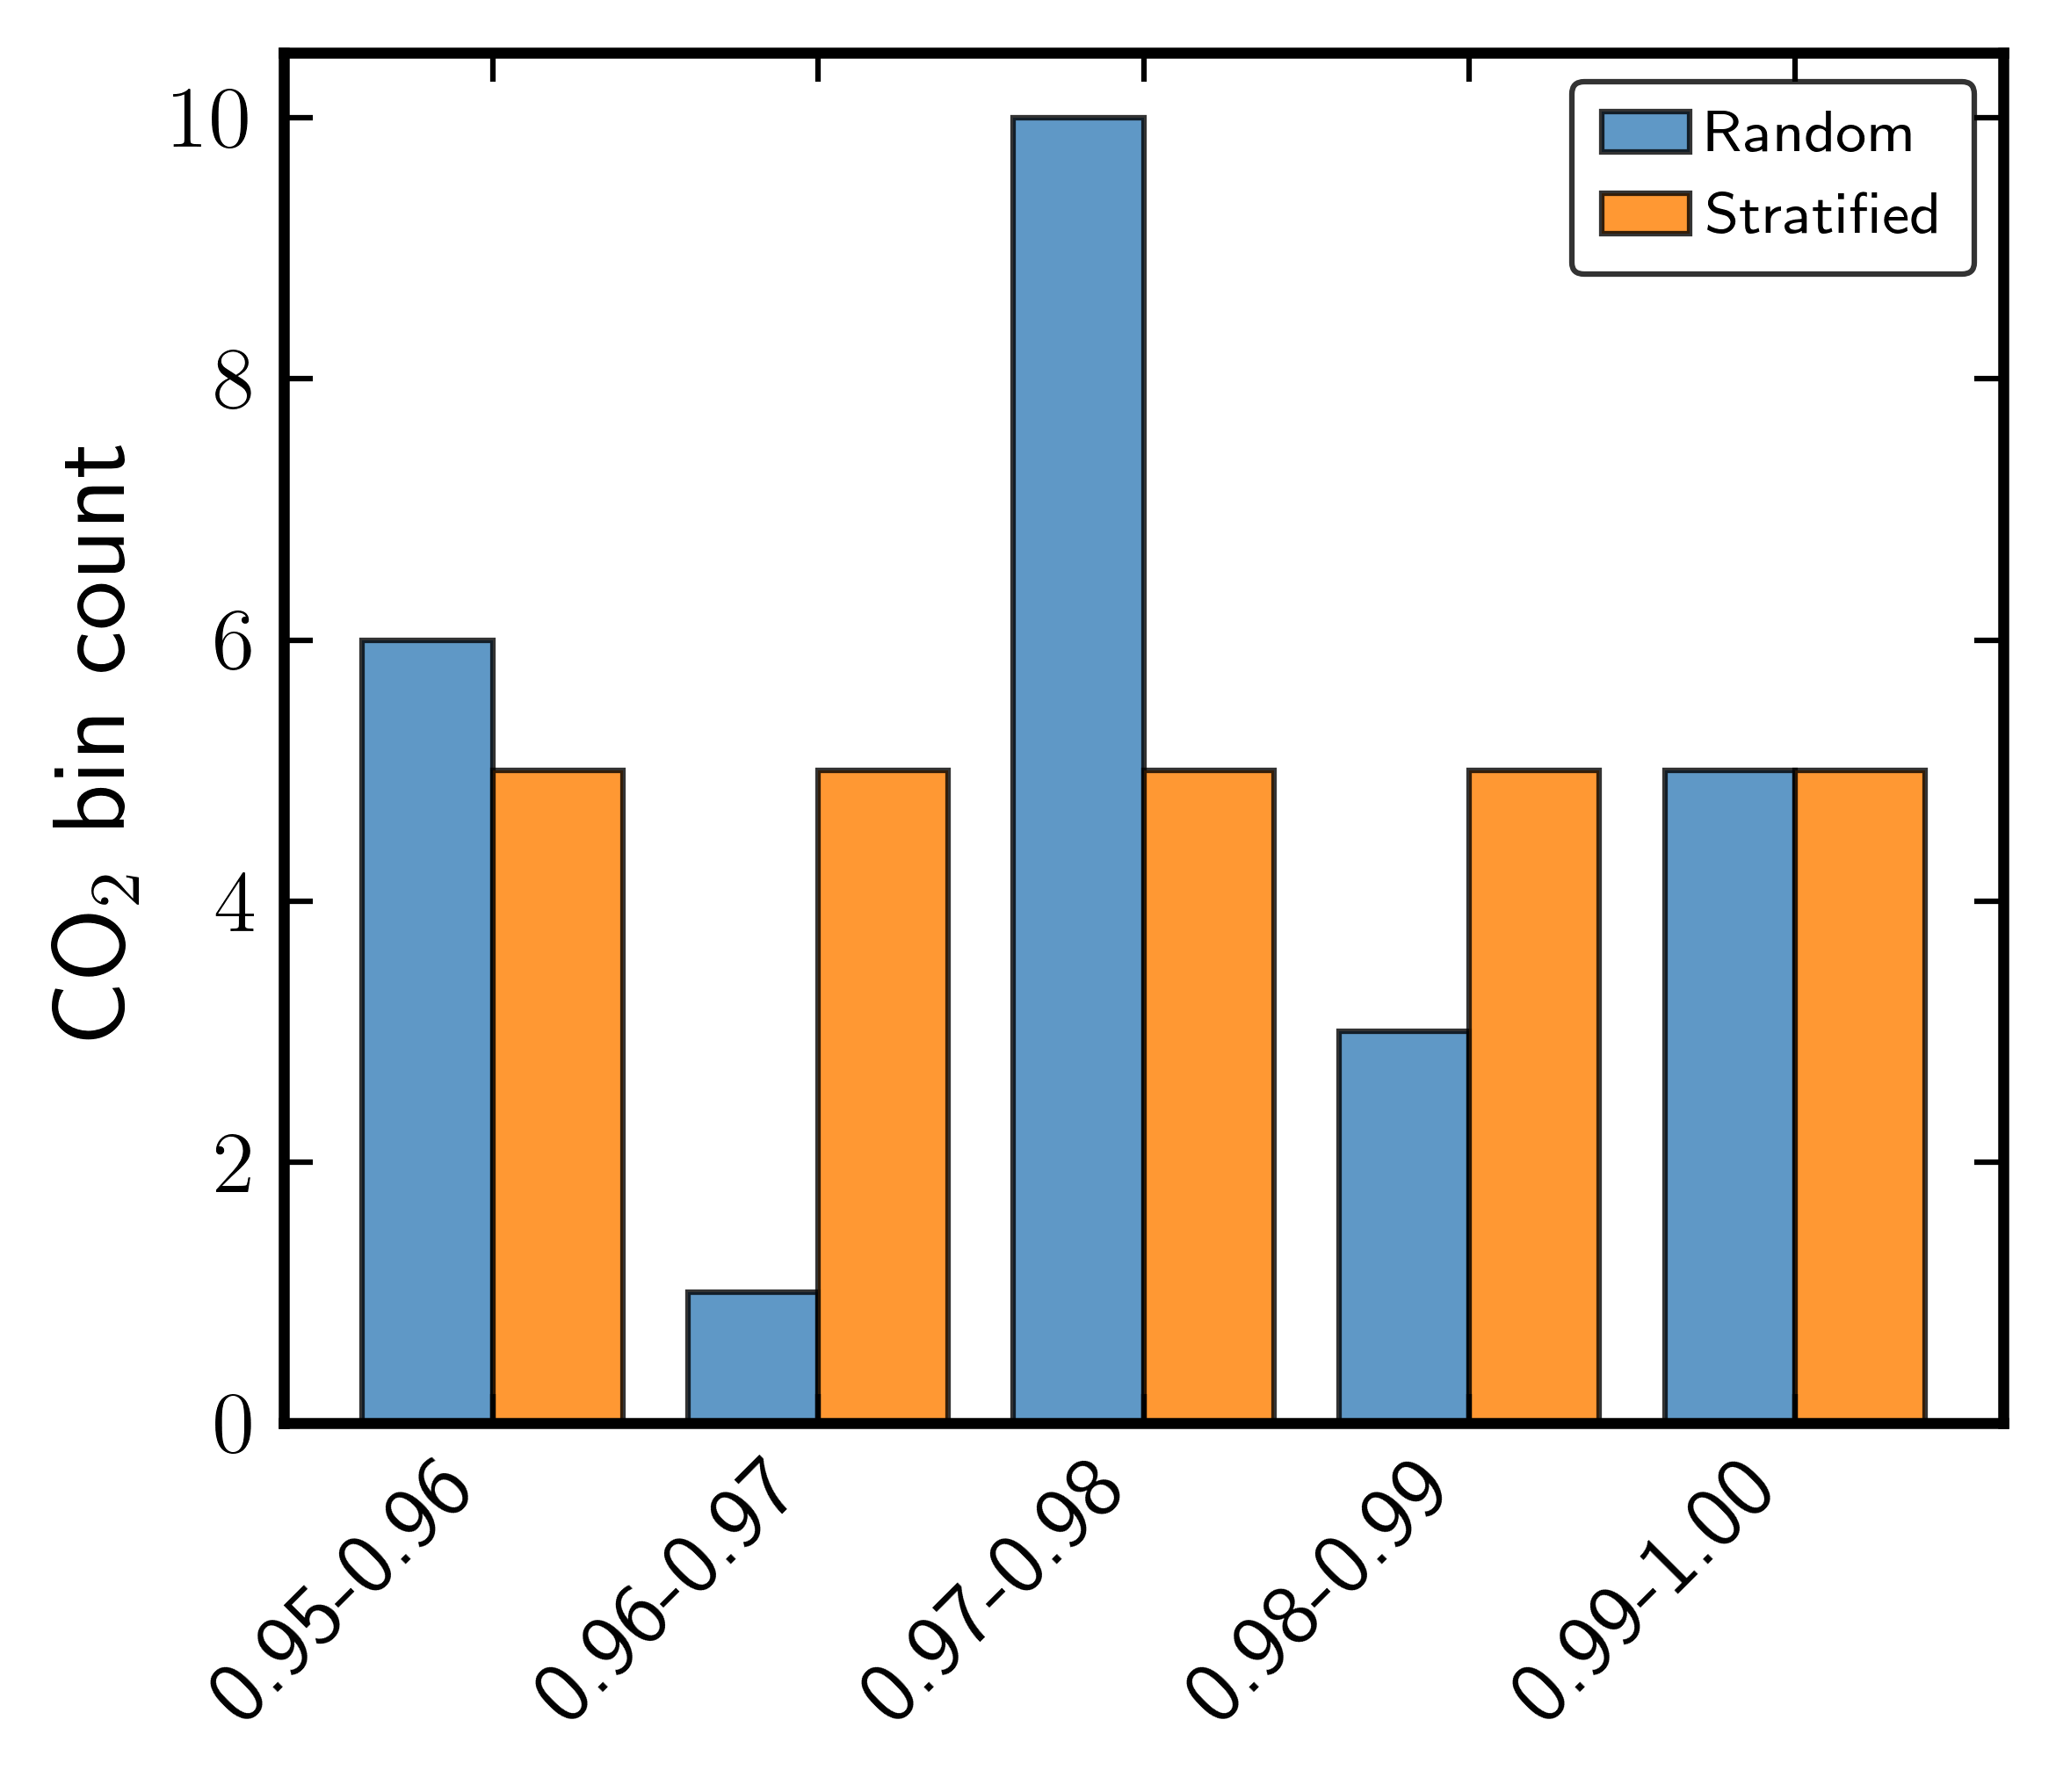

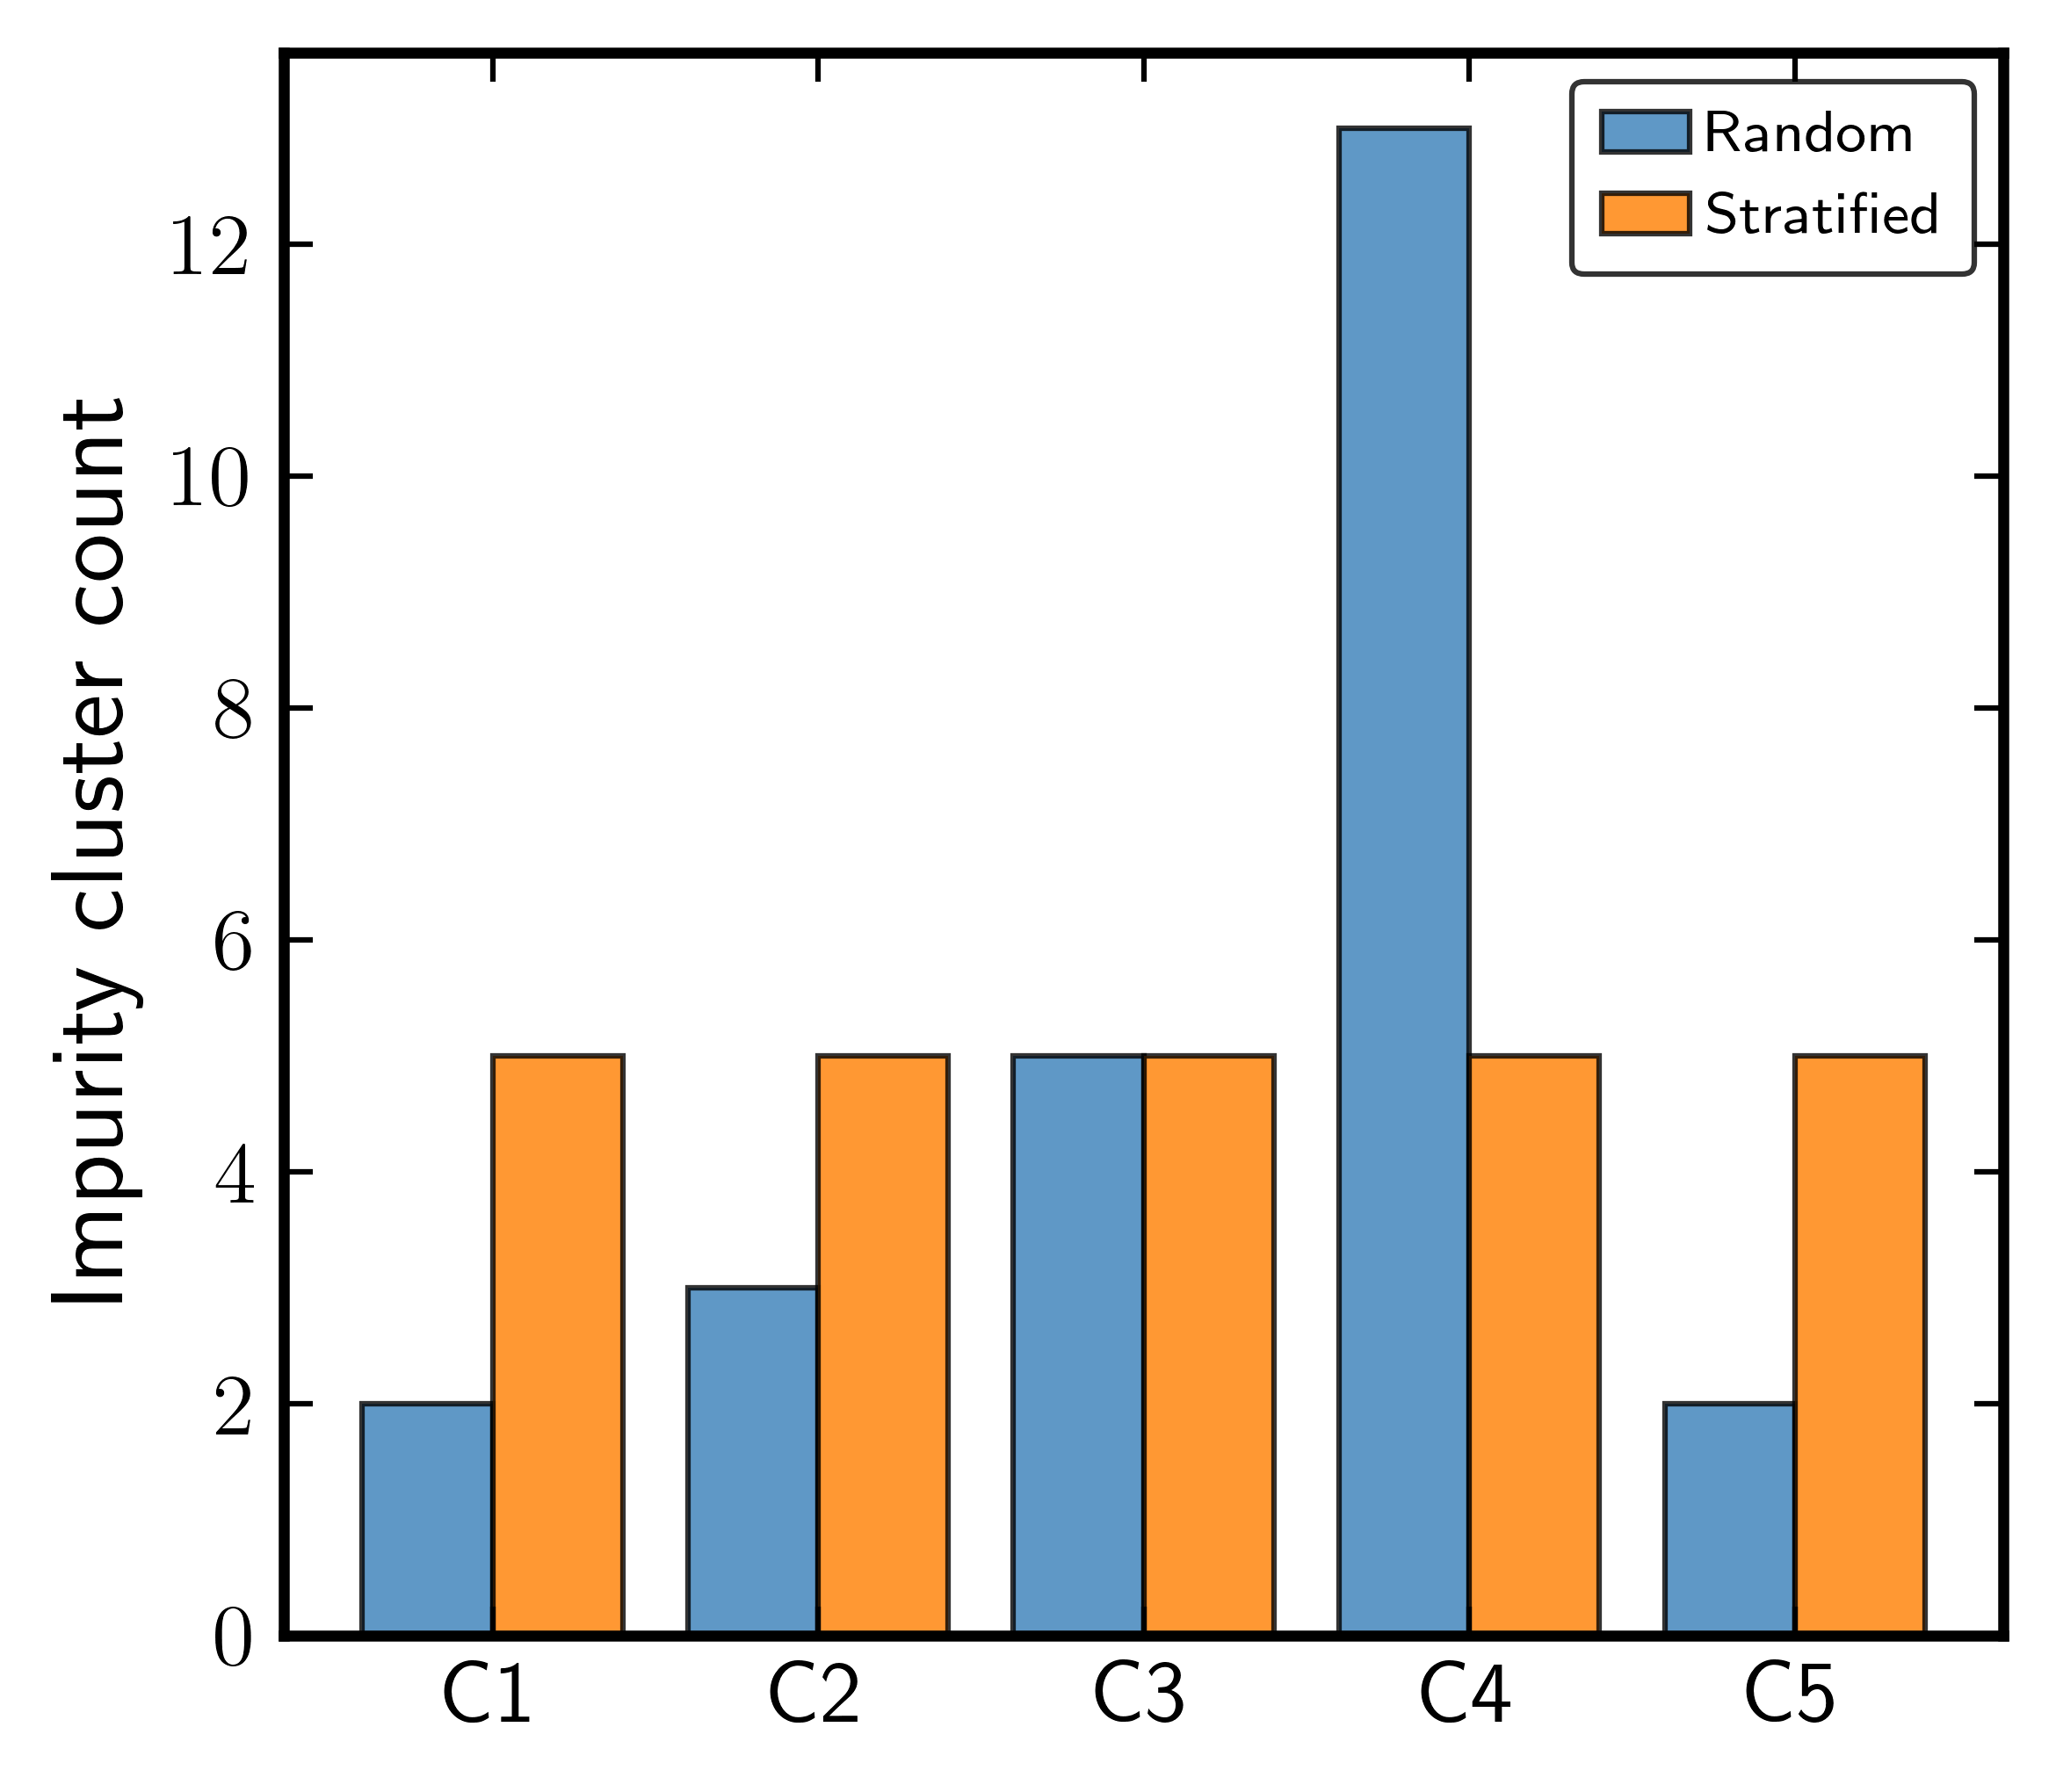

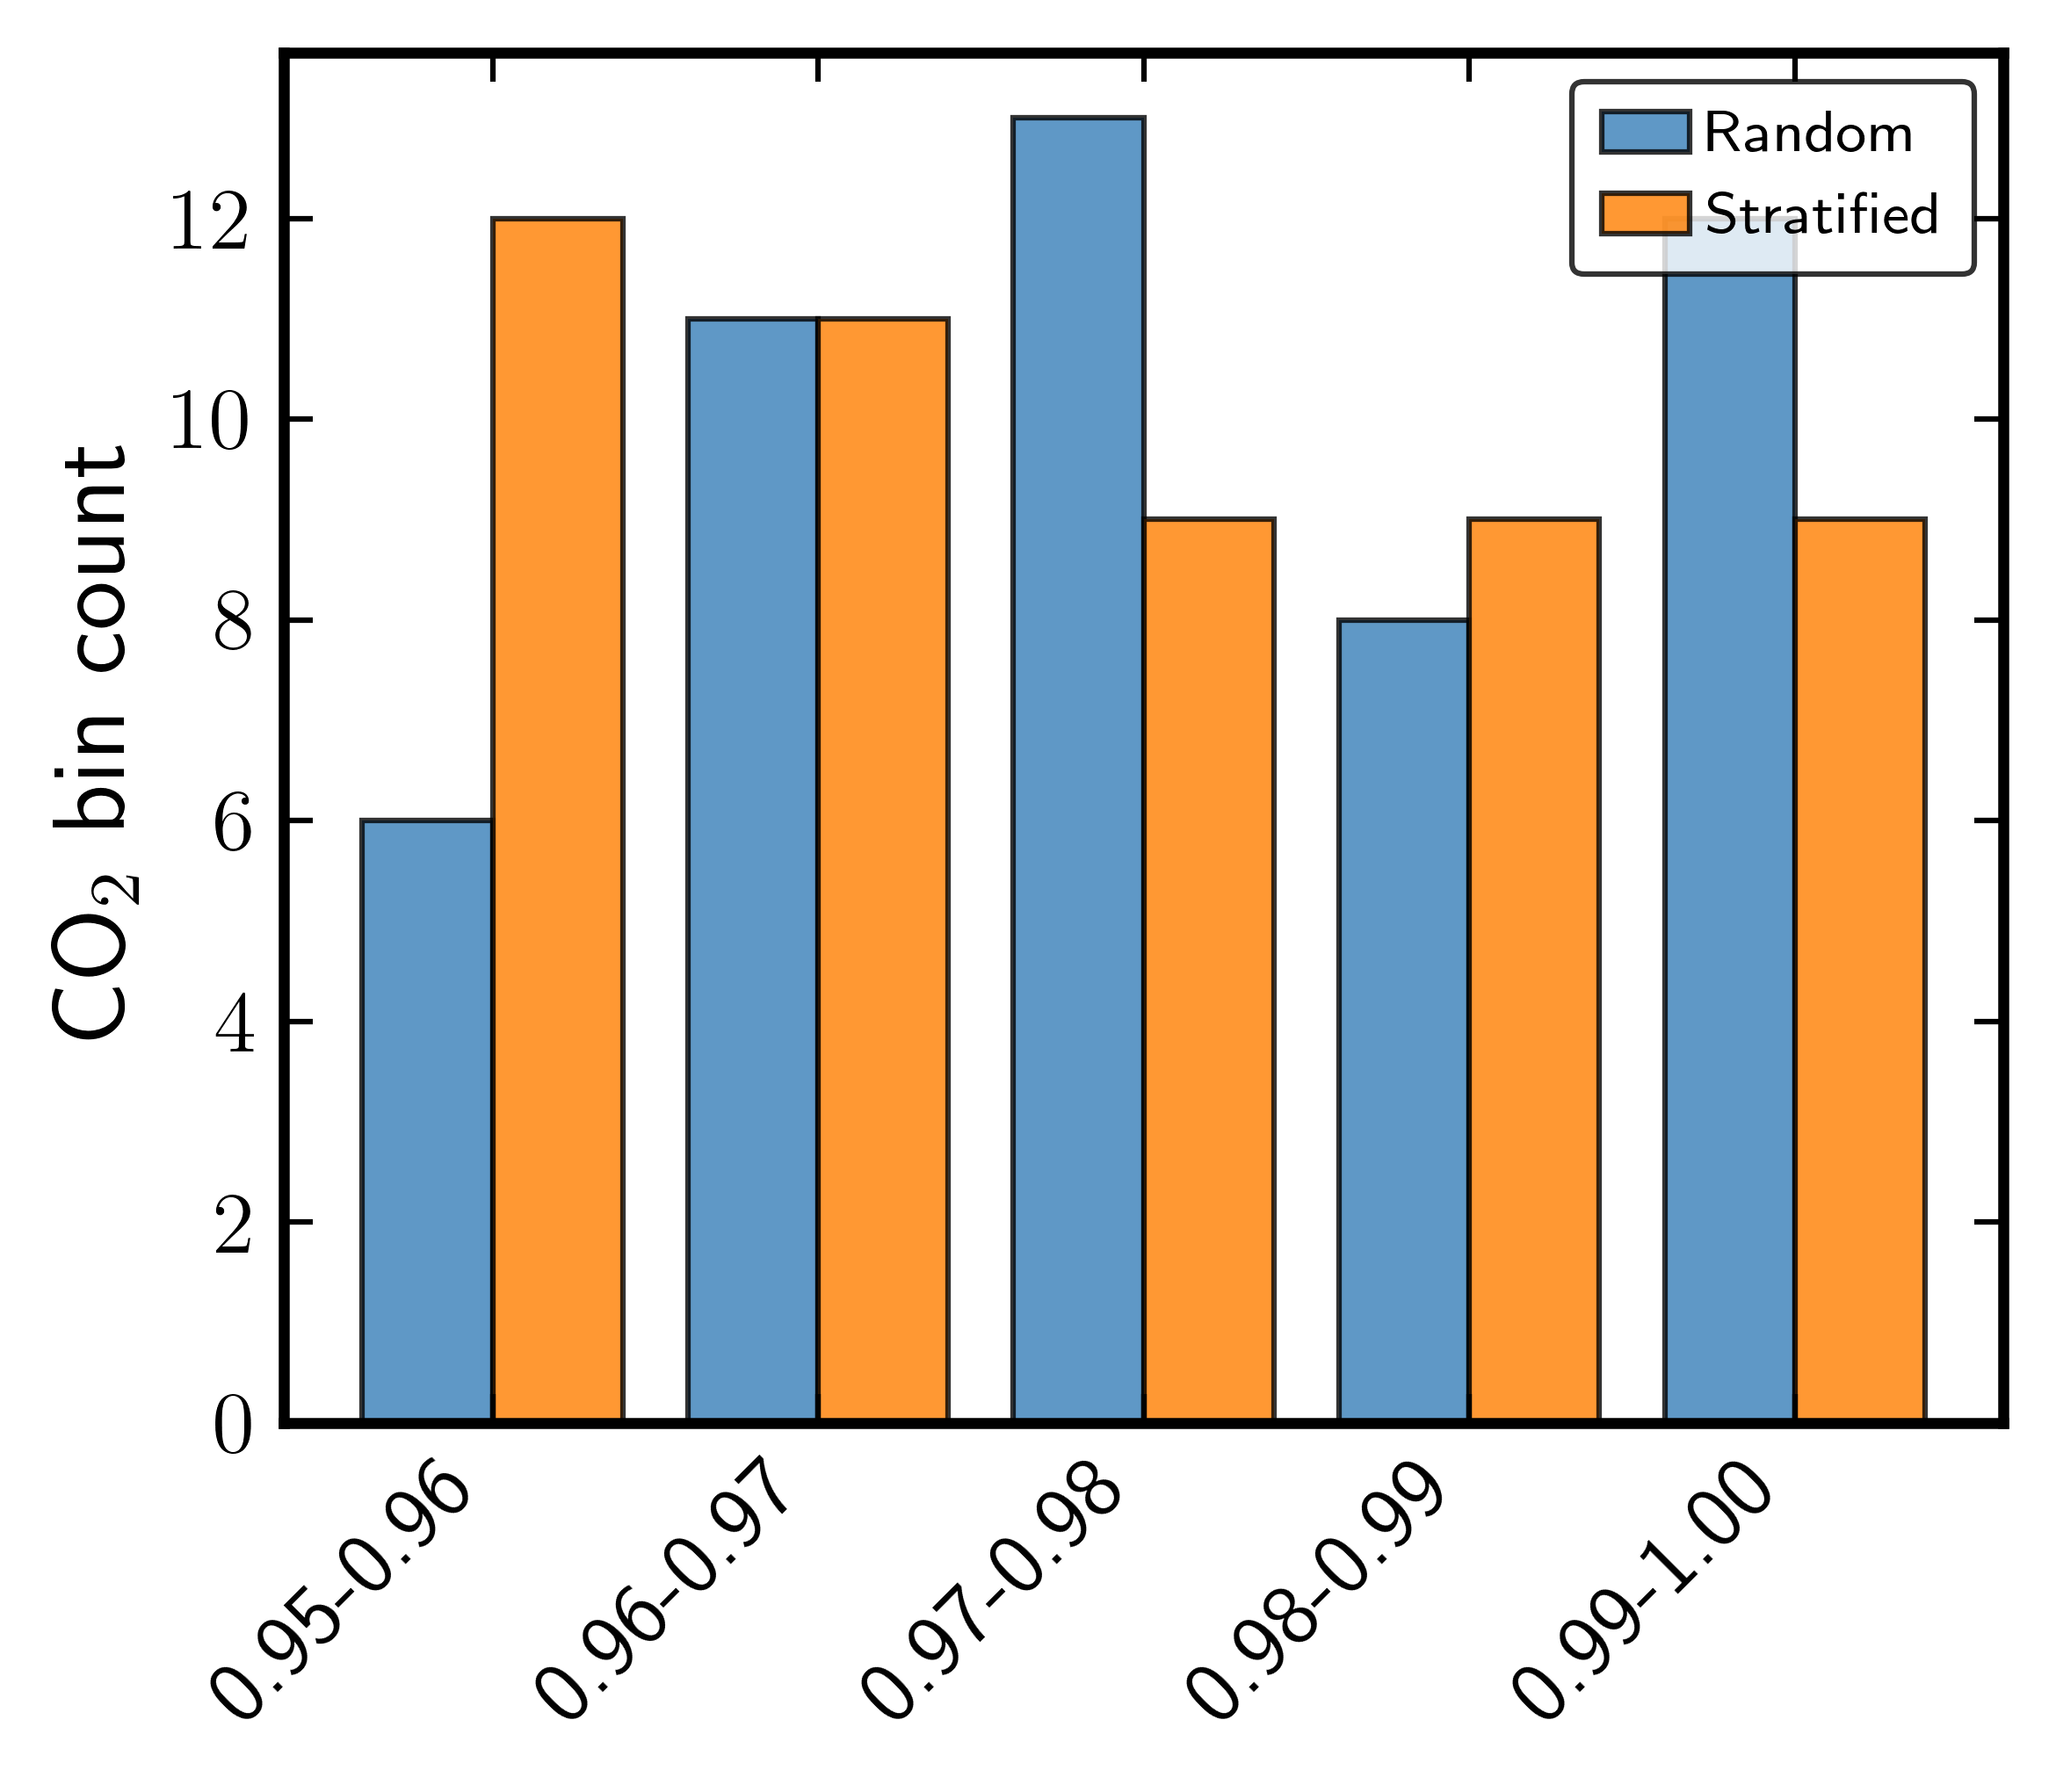

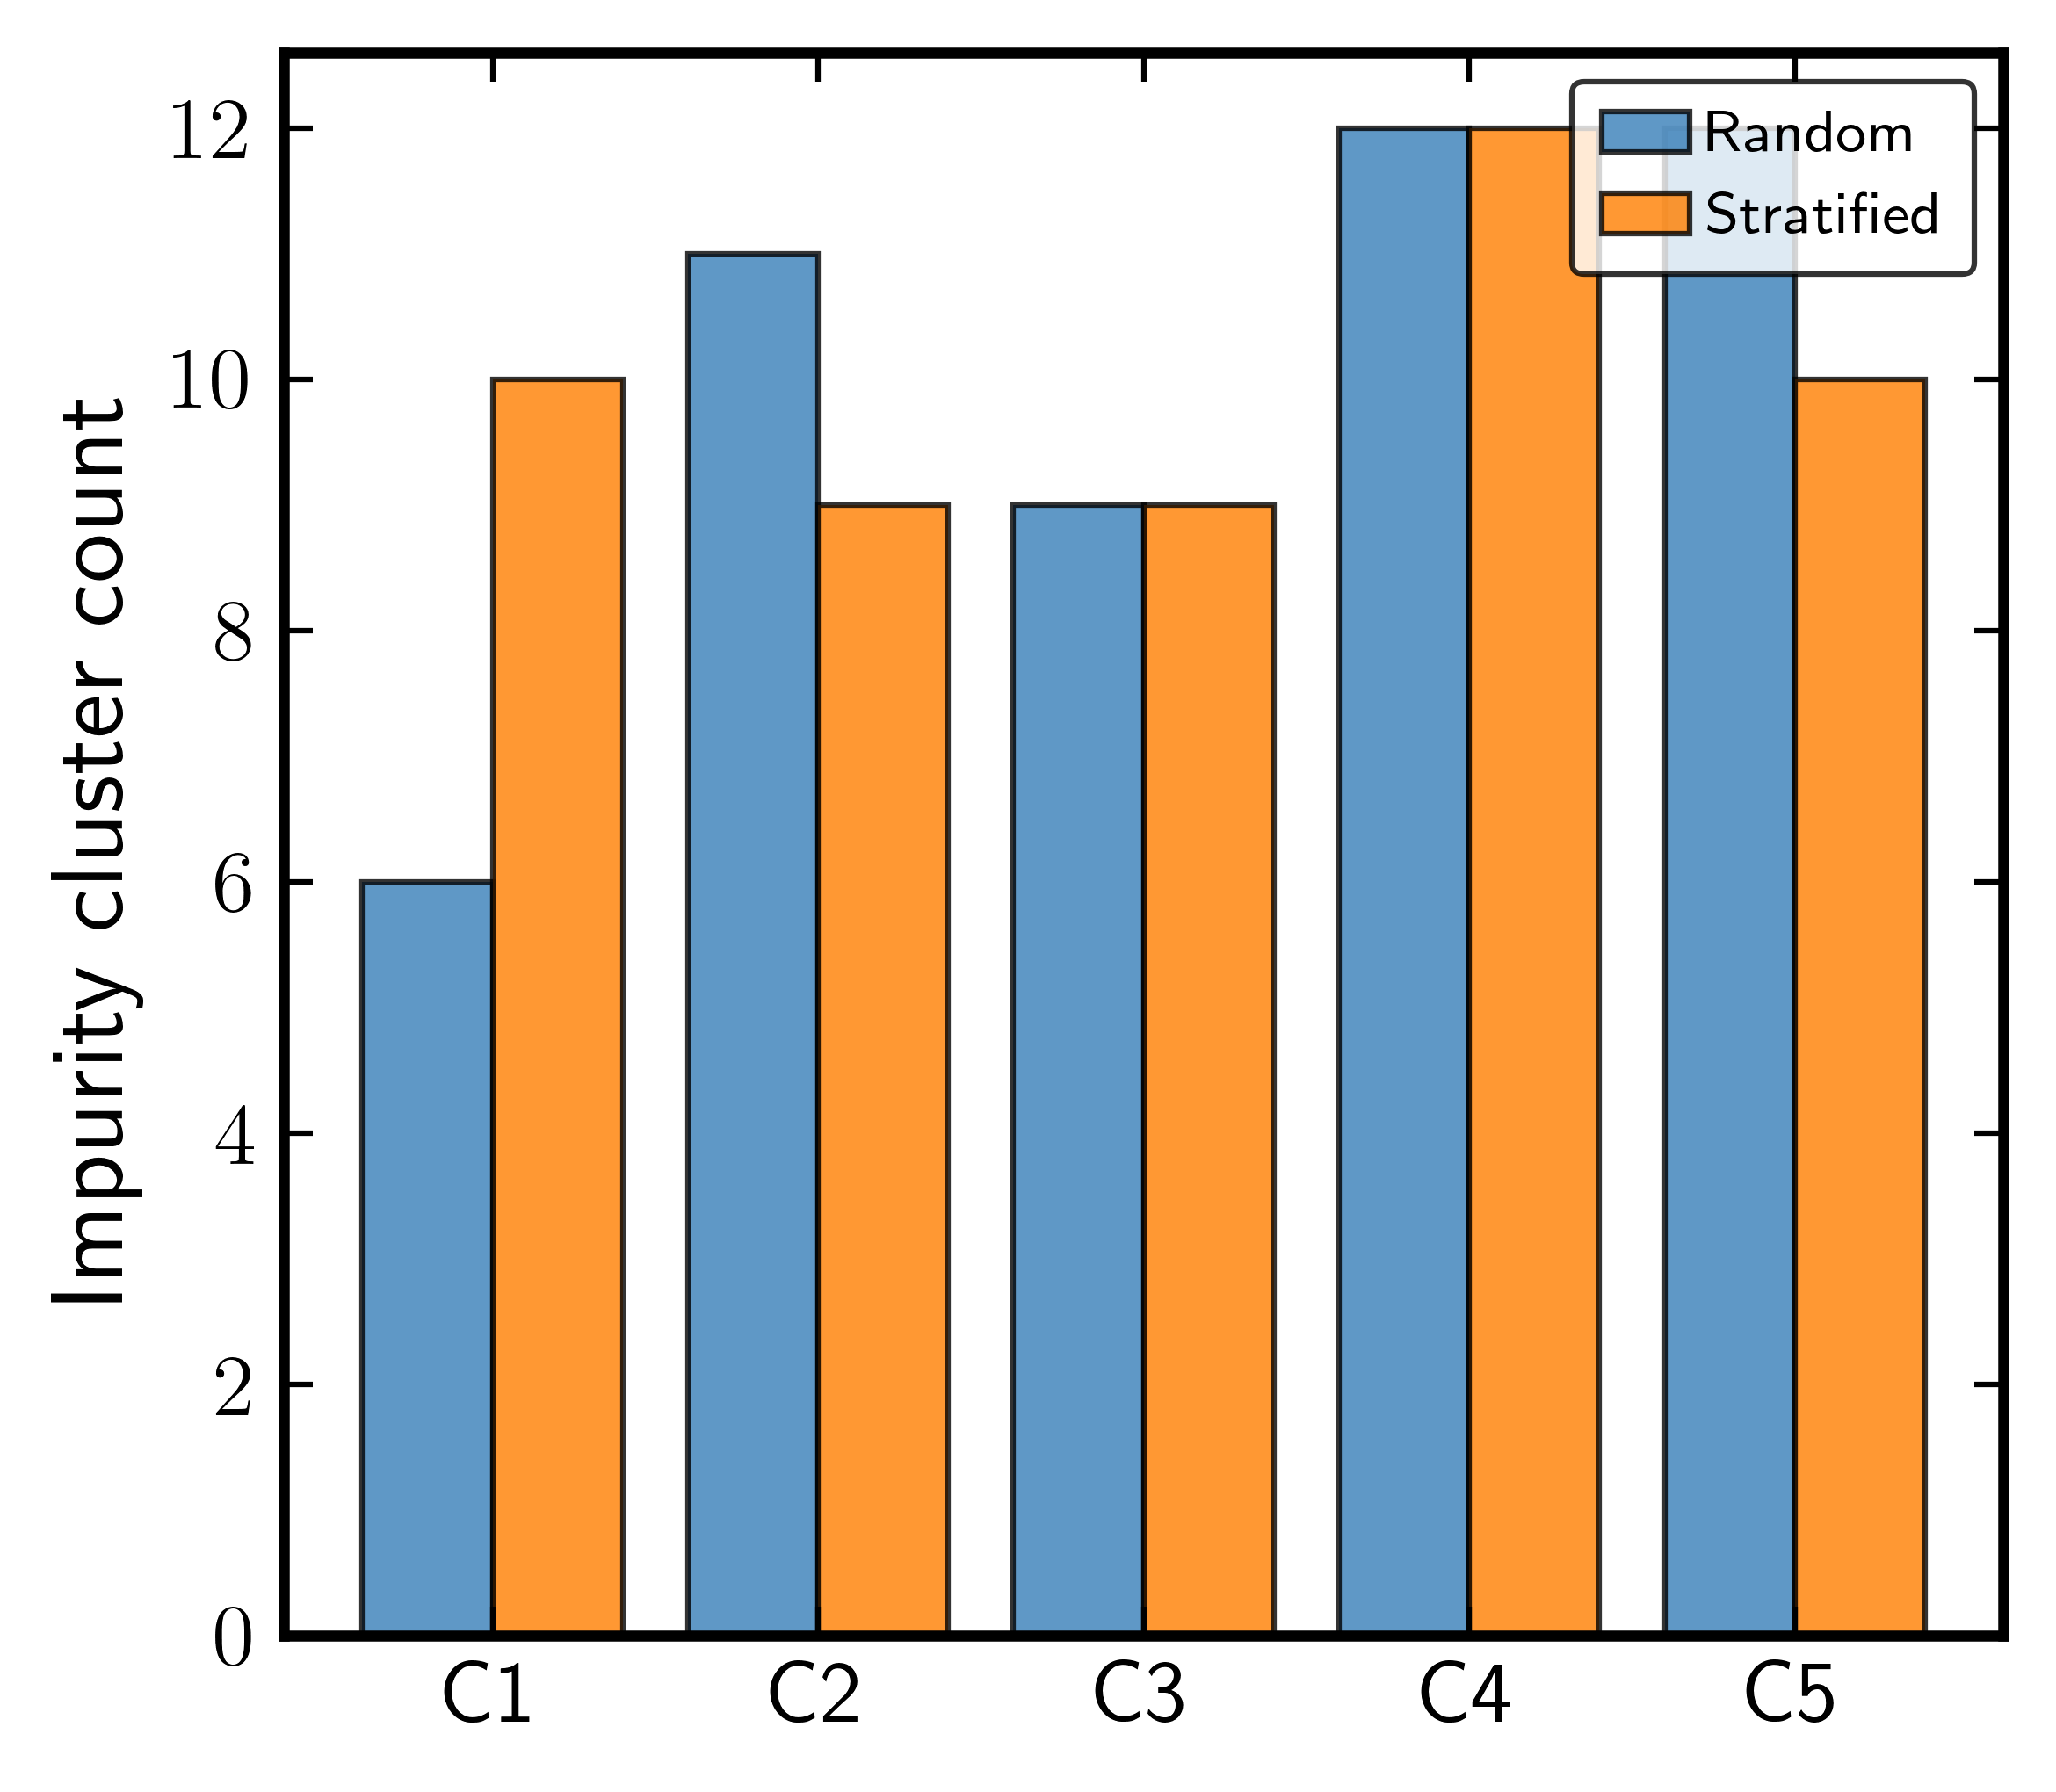

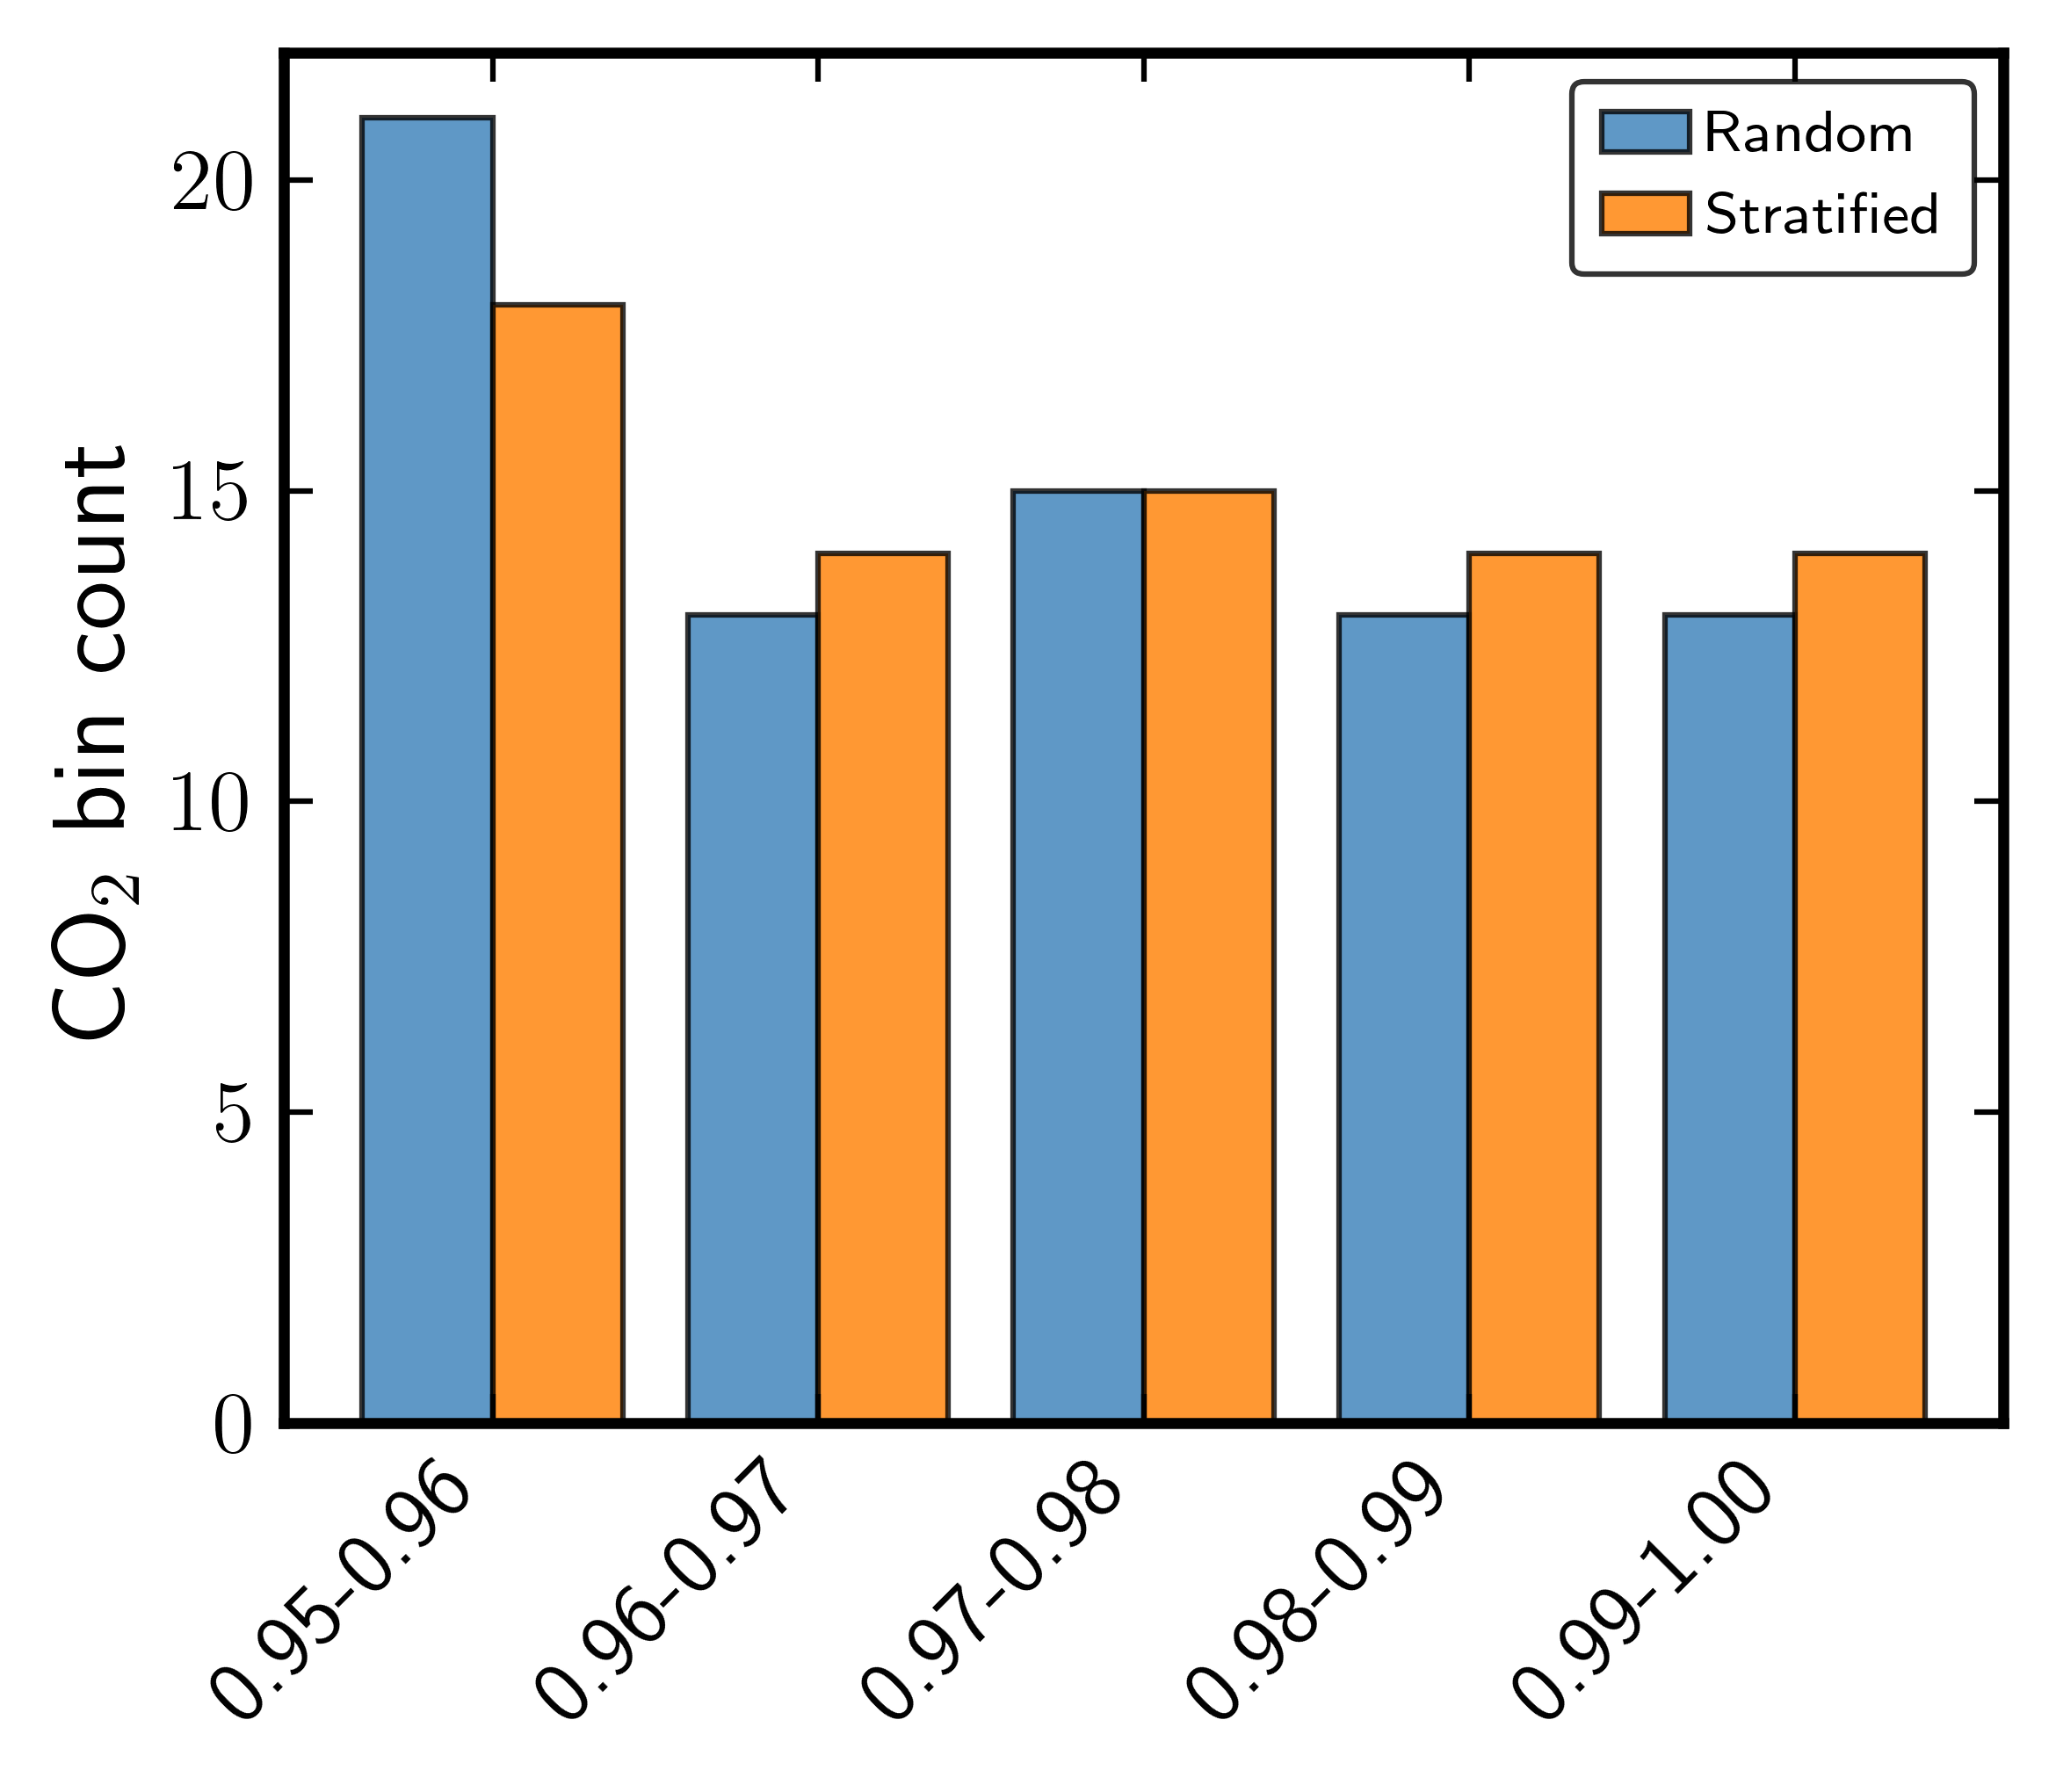

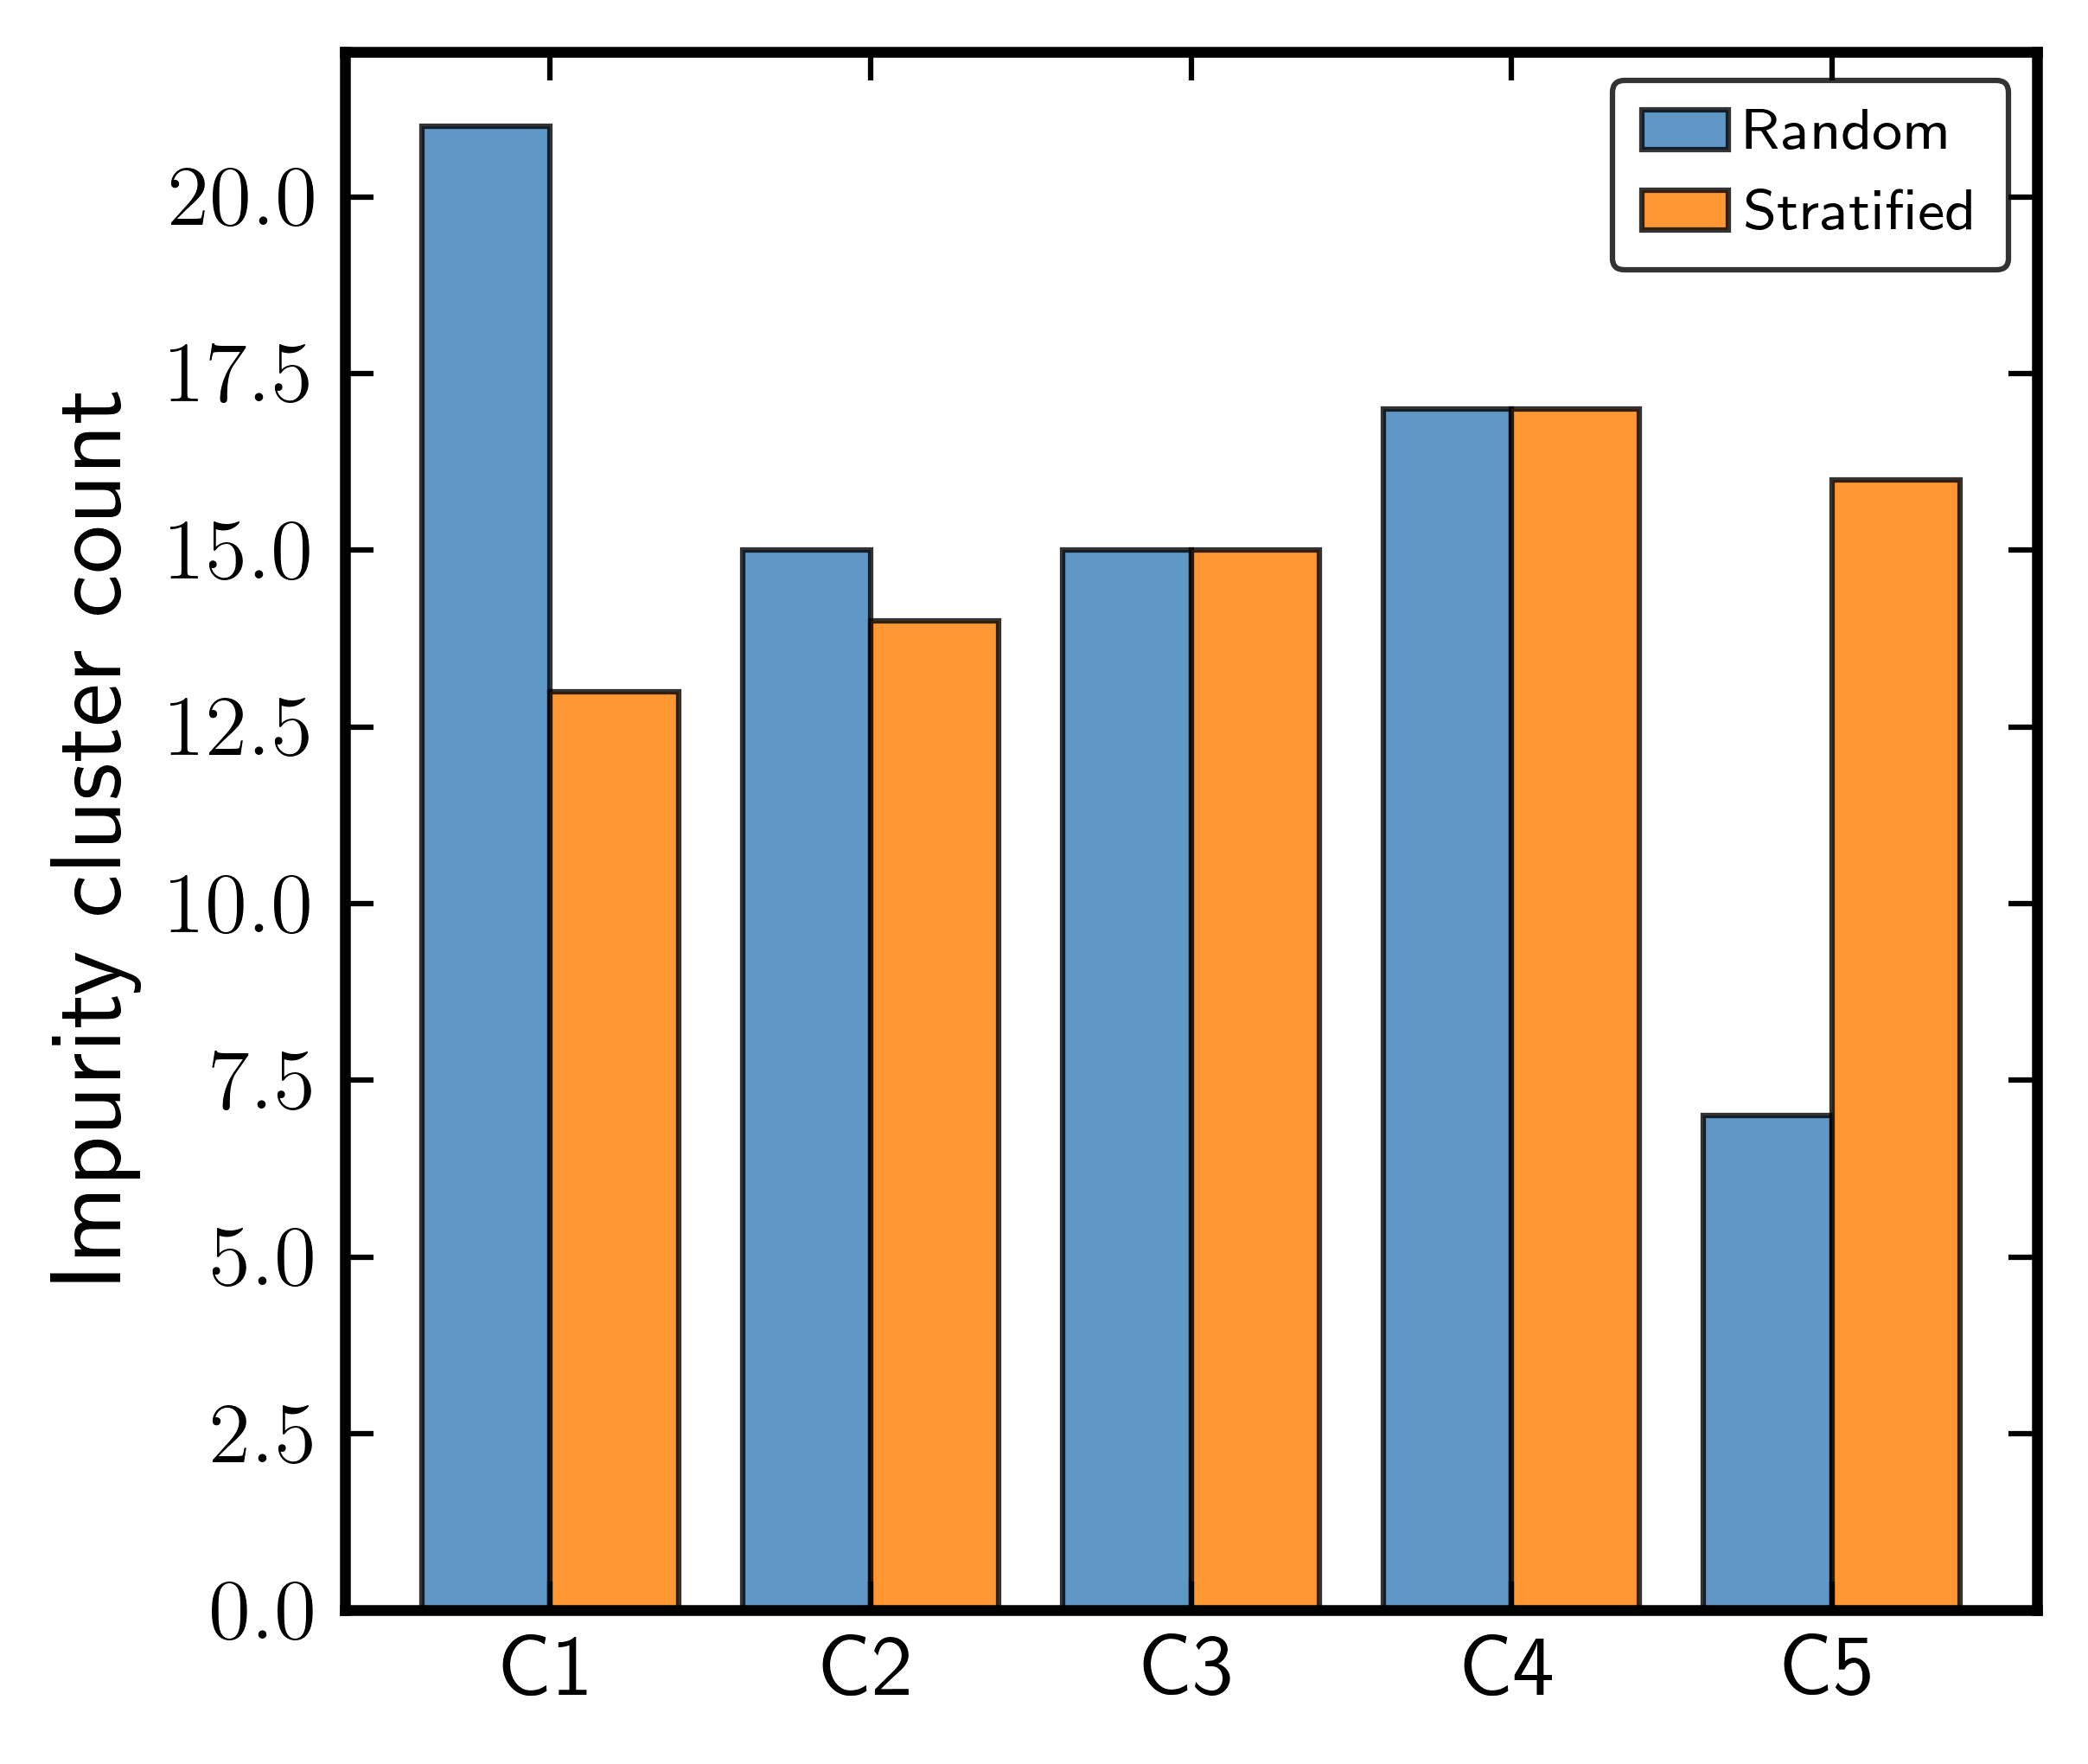

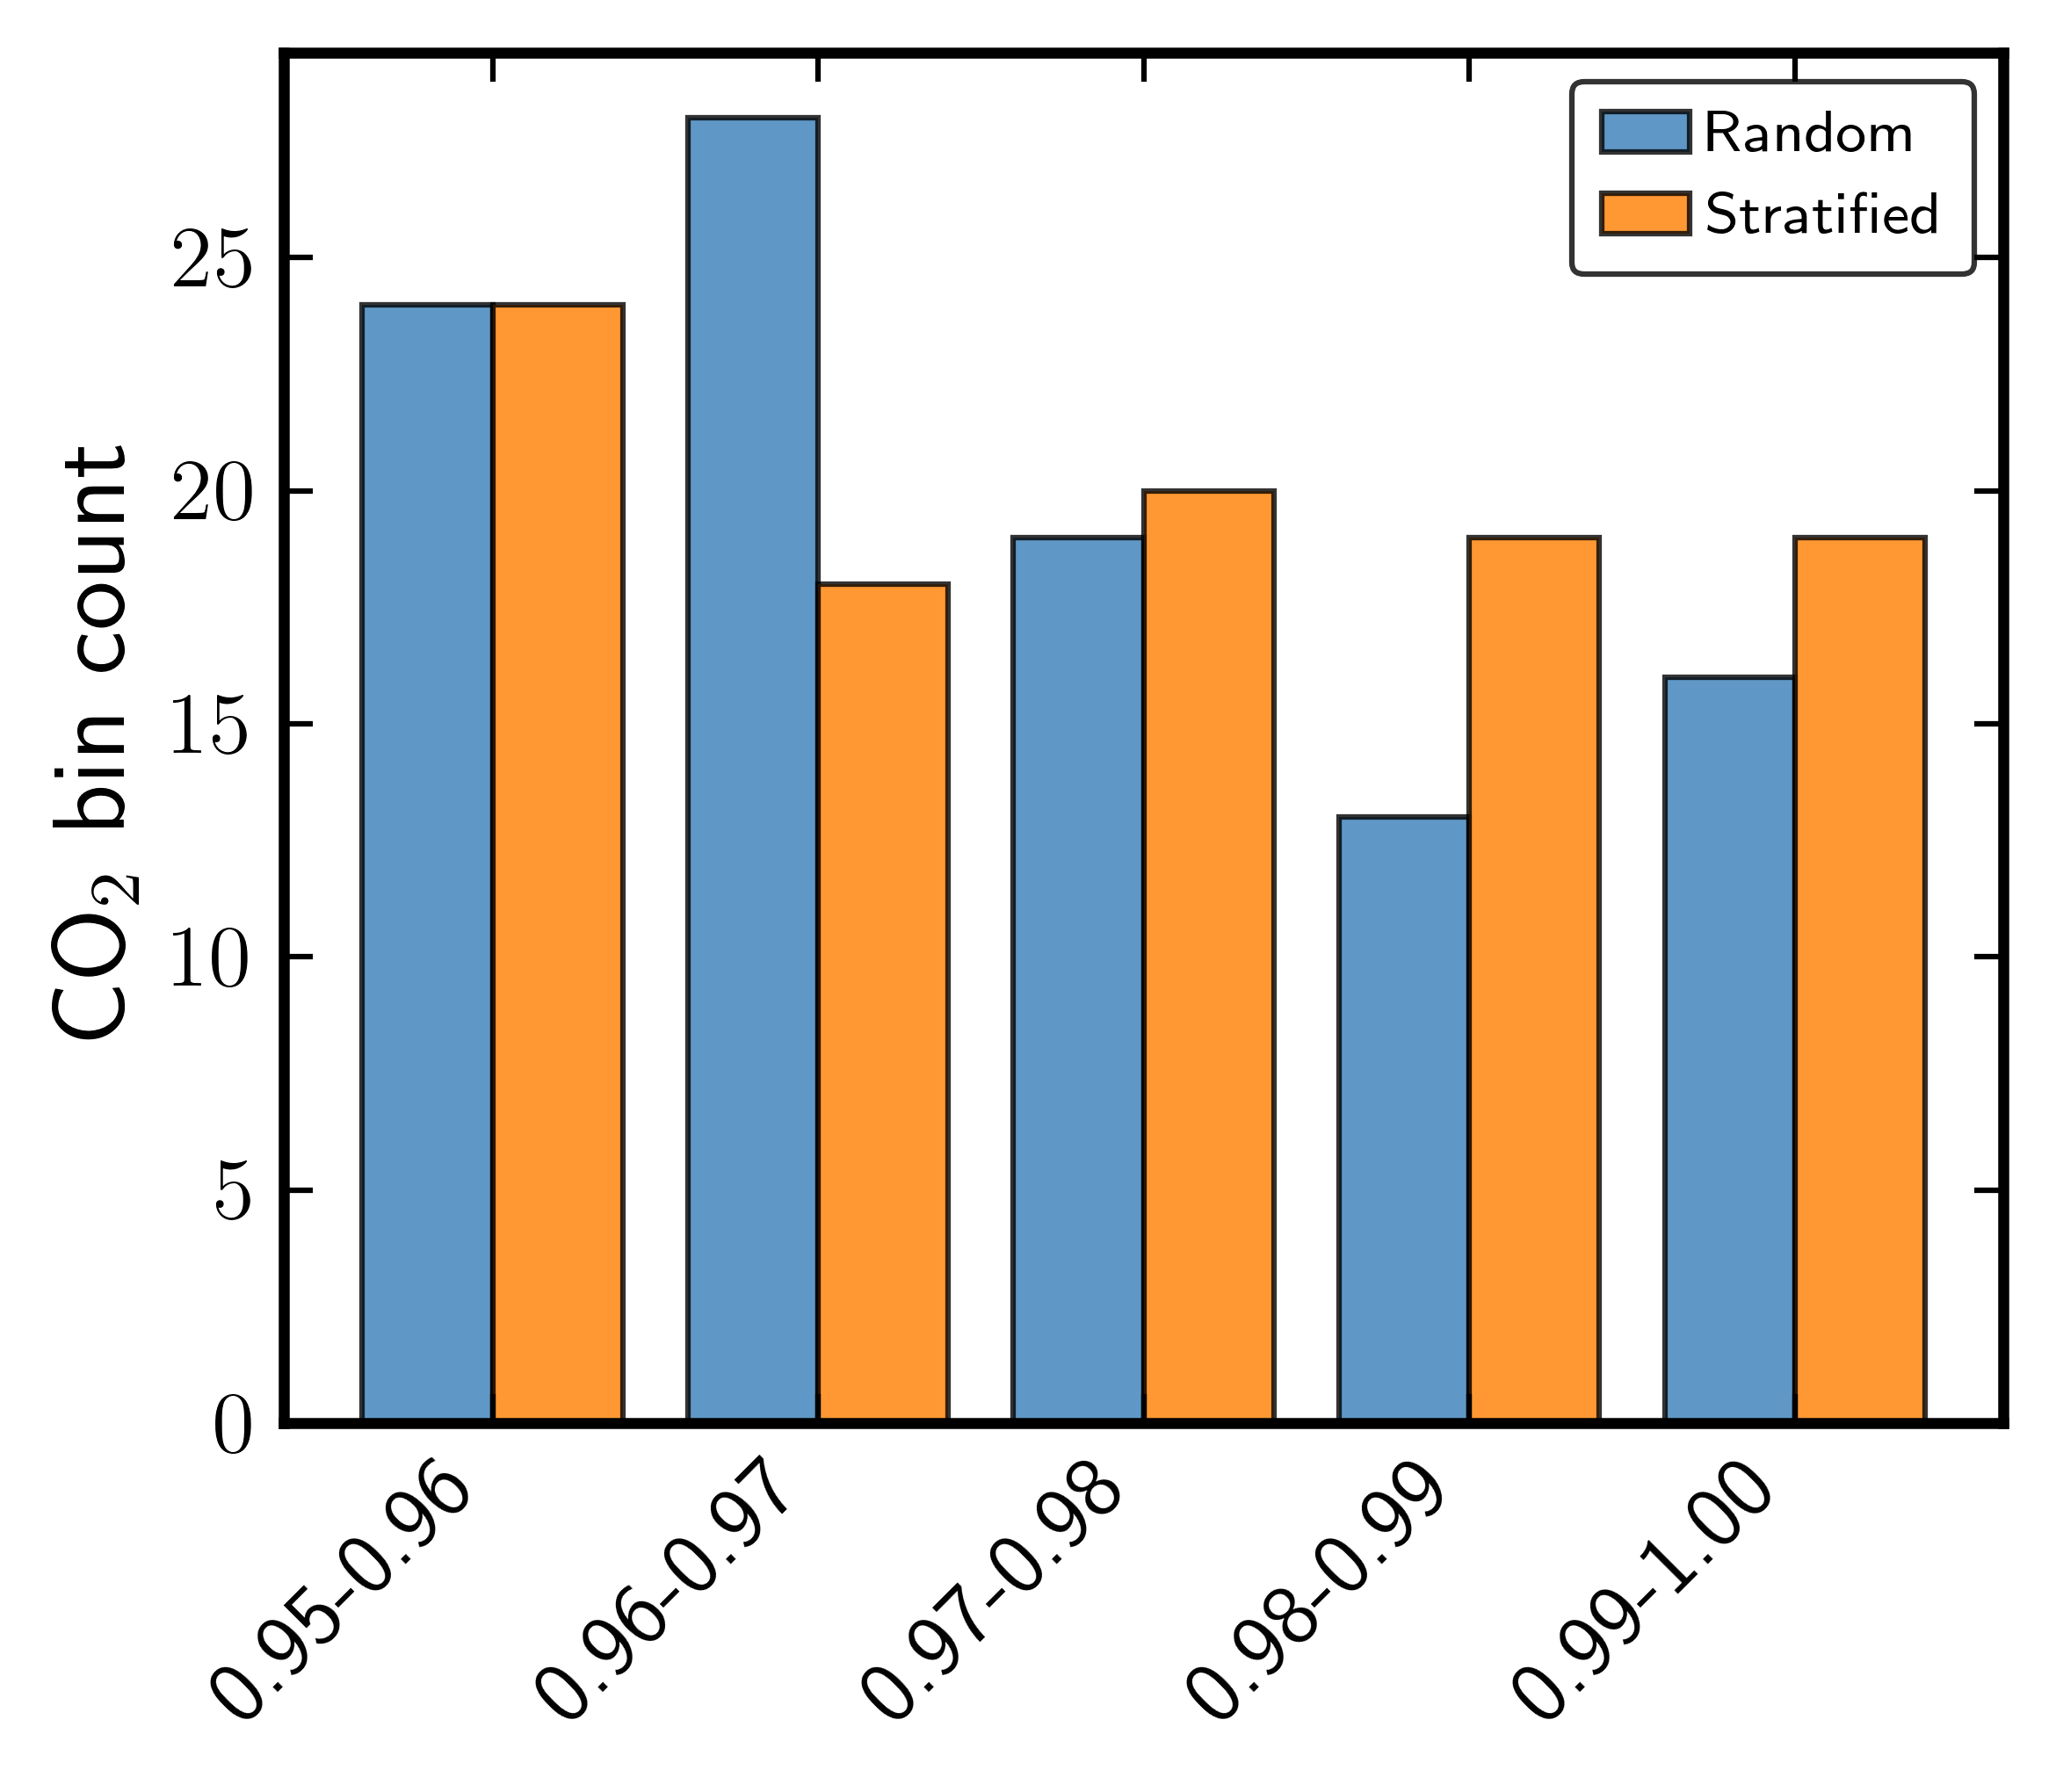

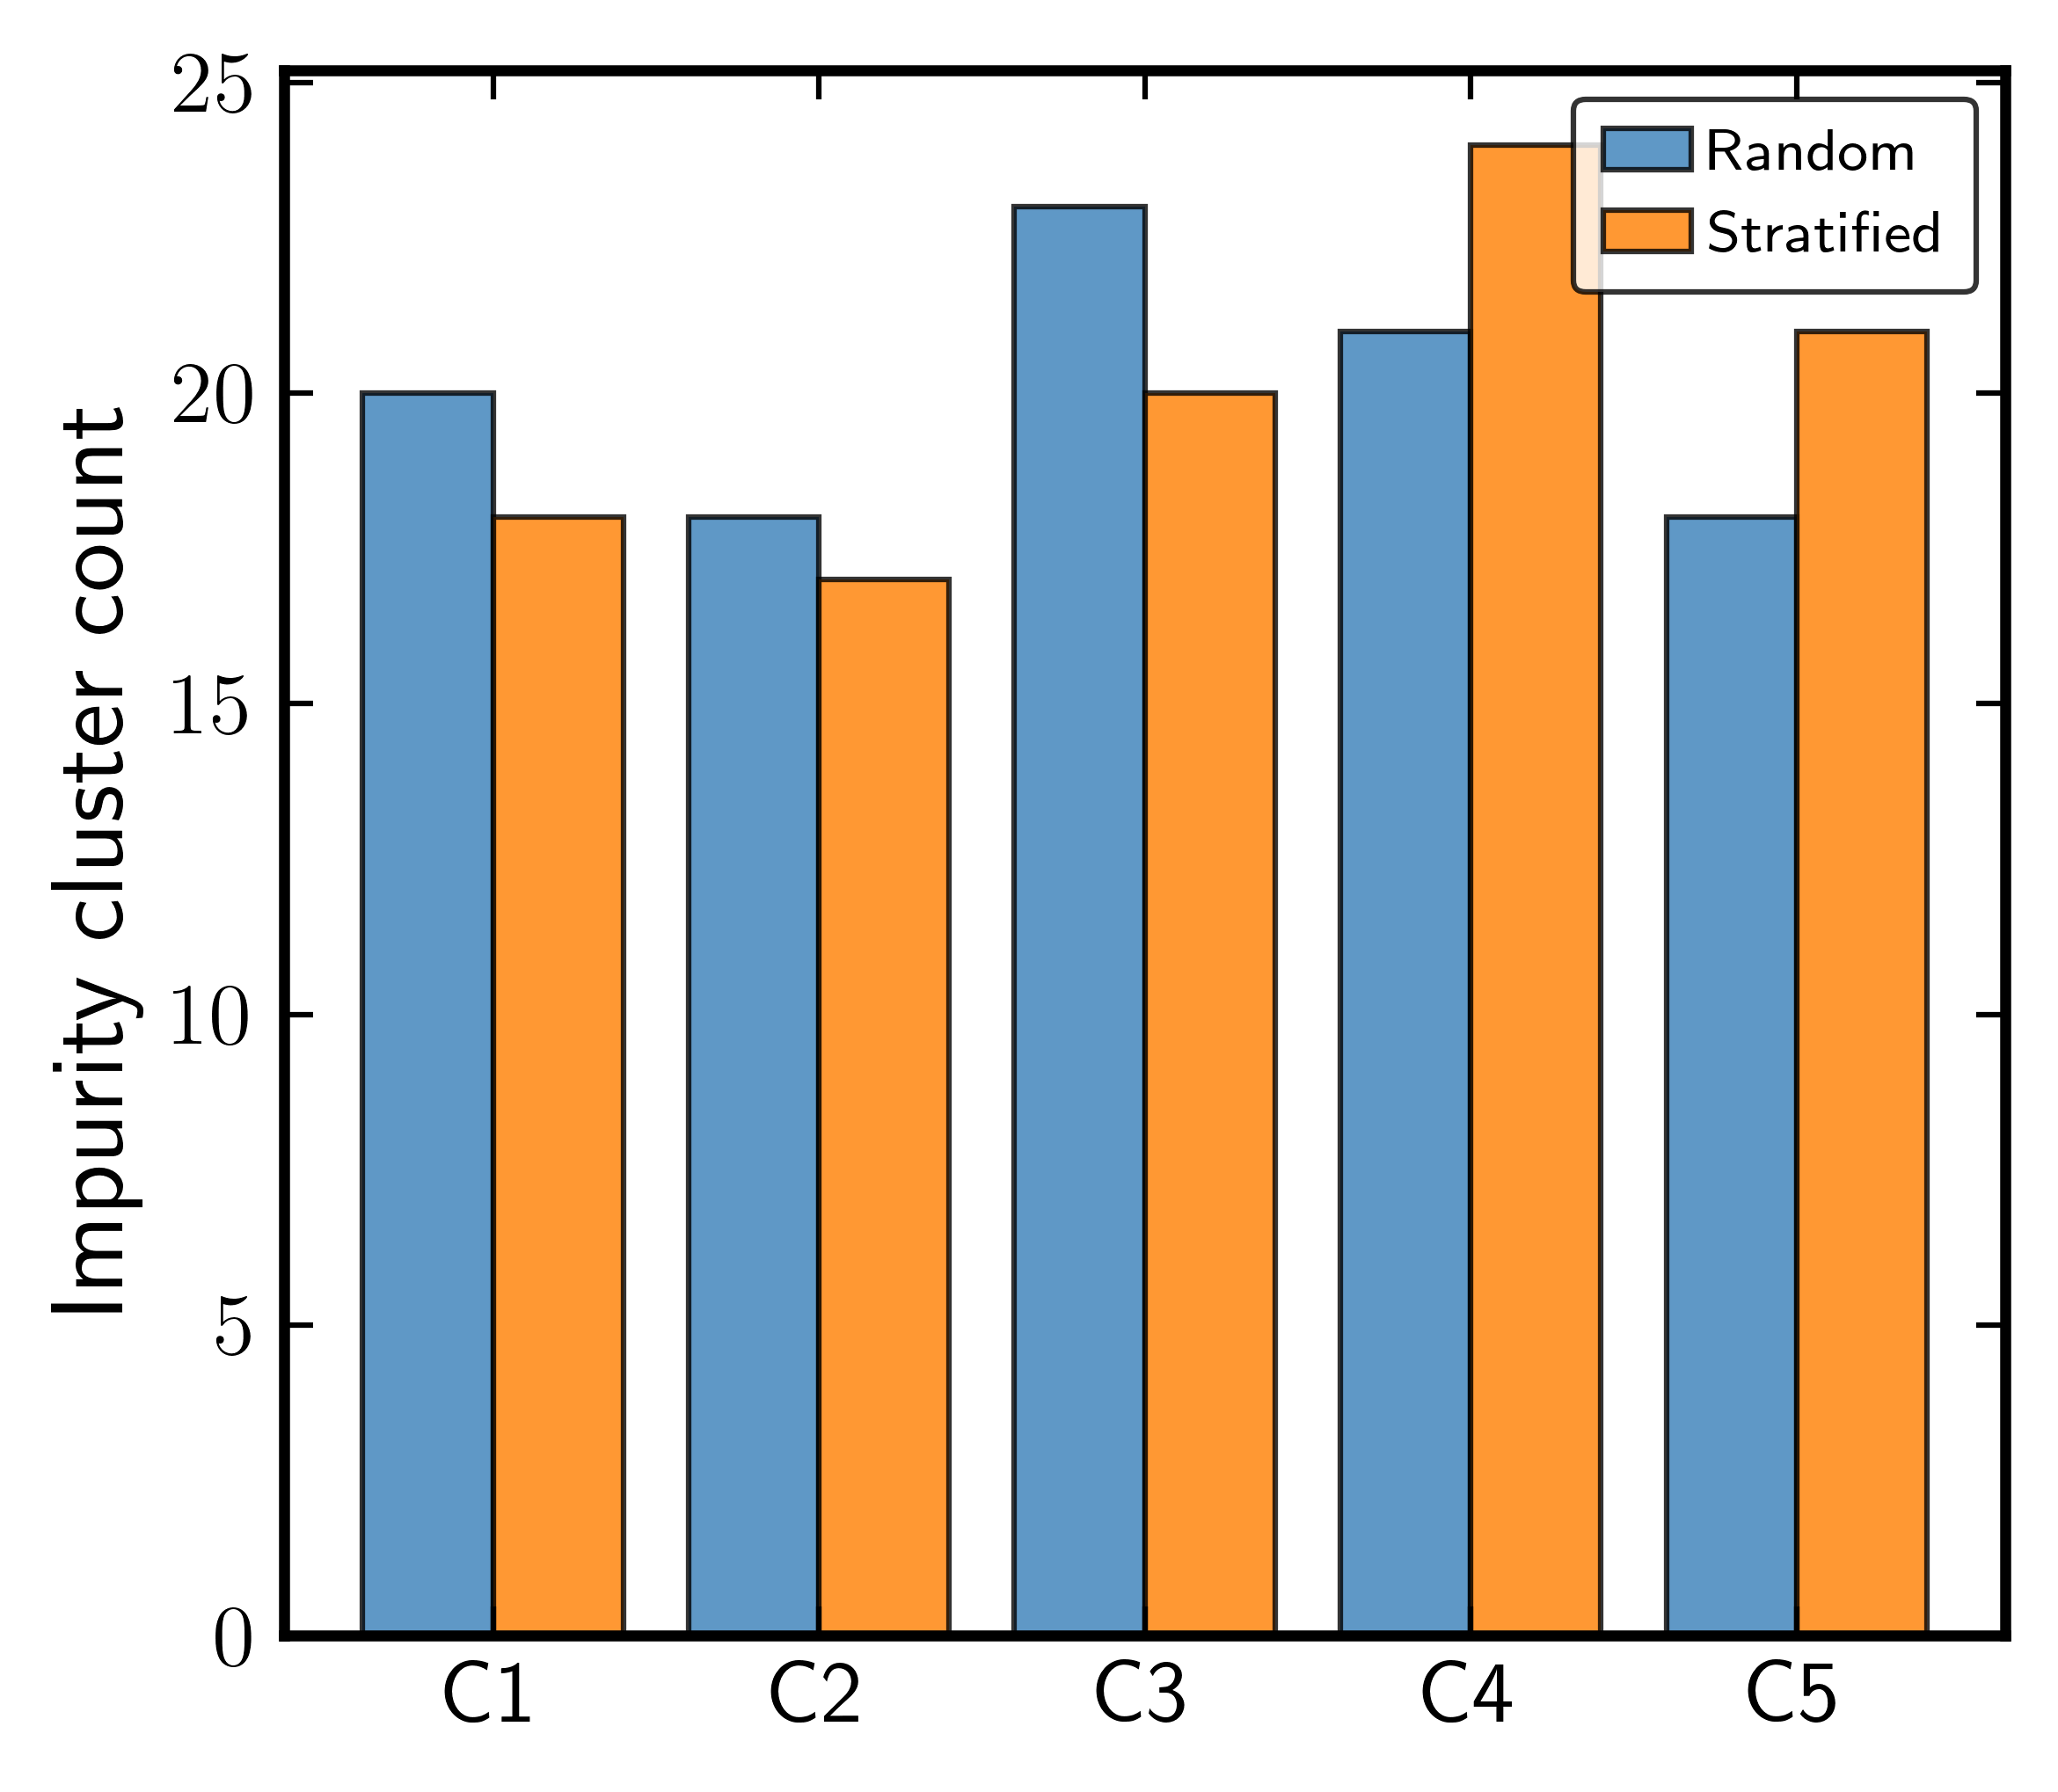

In [15]:
# ── Helper: predict impurity cluster using per-bin models ─────────────────────
def predict_bin_clusters(df_sub):
    co2_cut  = pd.cut(df_sub["CO2"].round(4), bins=CO2_BINS, labels=CO2_LABELS, right=False)
    clusters = np.full(len(df_sub), -1, dtype=int)
    for b in CO2_LABELS:
        mask = (co2_cut == b).values
        if mask.sum() == 0 or b not in scalers_per_bin:
            continue
        sub      = df_sub[mask]
        x_tot    = (1.0 - sub["CO2"].values).reshape(-1, 1)
        X_norm   = sub[IMPURITY_COLS].values / np.clip(x_tot, 1e-12, None)
        X_sc     = scalers_per_bin[b].transform(X_norm)
        clusters[mask] = kmeans_per_bin[b].predict(X_sc)
    return clusters


def plot_co2_coverage(ax, df_rand, df_strat, show_legend=True, show_ylabel=True):
    rand_bins  = pd.cut(df_rand["CO2"].round(4),  bins=CO2_BINS, labels=CO2_LABELS, right=False).value_counts().sort_index()
    strat_bins = pd.cut(df_strat["CO2"].round(4), bins=CO2_BINS, labels=CO2_LABELS, right=False).value_counts().sort_index()

    x = range(len(CO2_LABELS))
    ax.bar([i - 0.2 for i in x], rand_bins.values,  width=0.4, label="Random",     alpha=0.8, color=ps.colors[2], edgecolor="black", linewidth=ps.markeredgewidth)
    ax.bar([i + 0.2 for i in x], strat_bins.values, width=0.4, label="Stratified", alpha=0.8, color=ps.colors[3], edgecolor="black", linewidth=ps.markeredgewidth)
    ax.set_xticks(list(x))
    ax.set_xticklabels(CO2_LABELS, rotation=45, ha="right", fontsize=PLOT_TICK_LABELSIZE)
    ax.set_ylabel(r"CO$_2$ bin count" if show_ylabel else "", fontsize=PLOT_LABEL_FONTSIZE)
    if show_legend:
        ps.style_legend(ax, fontsize=PLOT_LEGEND_FONTSIZE)
    ps.apply_axis_style(ax)


def plot_cluster_coverage(ax, df_rand, df_strat, show_legend=True, show_ylabel=True):
    r_clusters = pd.Series(predict_bin_clusters(df_rand)).value_counts().sort_index()
    s_clusters = pd.Series(predict_bin_clusters(df_strat)).value_counts().sort_index()
    ck = range(K_IMP)

    ax.bar([i - 0.2 for i in ck], [r_clusters.get(c, 0) for c in ck], width=0.4, label="Random",     alpha=0.8, color=ps.colors[2], edgecolor="black", linewidth=ps.markeredgewidth)
    ax.bar([i + 0.2 for i in ck], [s_clusters.get(c, 0) for c in ck], width=0.4, label="Stratified", alpha=0.8, color=ps.colors[3], edgecolor="black", linewidth=ps.markeredgewidth)
    ax.set_xticks(list(ck))
    ax.set_xticklabels([f"C{c + 1}" for c in ck], fontsize=PLOT_TICK_LABELSIZE)
    ax.set_ylabel("Impurity cluster count" if show_ylabel else "", fontsize=PLOT_LABEL_FONTSIZE)
    if show_legend:
        ps.style_legend(ax, fontsize=PLOT_LEGEND_FONTSIZE)
    ps.apply_axis_style(ax)


# ── Plot: Random vs Stratified coverage comparison (trial 0) ──────────────────
PLOTS_DIR = OUTPUT_DIR / "PLOTS"
PLOTS_DIR.mkdir(exist_ok=True)
coverage_data = {}

for N in N_SIZES:
    rand_path  = Path("Random_Sampling") / f"N{N:03d}" / "trial_00.csv"
    strat_path = OUTPUT_DIR / f"N{N:03d}" / "trial_00.csv"
    coverage_data[N] = (pd.read_csv(rand_path), pd.read_csv(strat_path))

fig_co2, axes_co2 = ps.plot_init_multi(1, len(N_SIZES), w=14, h=3.5)
axes_co2 = np.atleast_1d(axes_co2).flatten()
for col, (N, (df_rand, df_strat)) in enumerate(coverage_data.items()):
    plot_co2_coverage(axes_co2[col], df_rand, df_strat, show_legend=(col == 0), show_ylabel=(col == 0))
fig_co2.tight_layout()
fig_co2.savefig(PLOTS_DIR / "random_vs_stratified_trial_00_co2_bins_all.png", dpi=ps.resolution_value, bbox_inches="tight")
fig_co2.savefig(PLOTS_DIR / "random_vs_stratified_trial_00_co2_bins_all.pdf", bbox_inches="tight")
plt.show()

fig_clusters, axes_clusters = ps.plot_init_multi(1, len(N_SIZES), w=14, h=3.5)
axes_clusters = np.atleast_1d(axes_clusters).flatten()
for col, (N, (df_rand, df_strat)) in enumerate(coverage_data.items()):
    plot_cluster_coverage(axes_clusters[col], df_rand, df_strat, show_legend=(col == 0), show_ylabel=(col == 0))
fig_clusters.tight_layout()
fig_clusters.savefig(PLOTS_DIR / "random_vs_stratified_trial_00_impurity_clusters_all.png", dpi=ps.resolution_value, bbox_inches="tight")
fig_clusters.savefig(PLOTS_DIR / "random_vs_stratified_trial_00_impurity_clusters_all.pdf", bbox_inches="tight")
plt.show()

# ── Save each N separately, split by plot type ────────────────────────────────
for N, (df_rand, df_strat) in coverage_data.items():
    fig_n_co2, ax_n_co2 = ps.plot_init(w=4, h=3.5)
    plot_co2_coverage(ax_n_co2, df_rand, df_strat, show_legend=True, show_ylabel=True)
    fig_n_co2.tight_layout()
    fig_n_co2.savefig(PLOTS_DIR / f"random_vs_stratified_trial_00_N{N:03d}_co2_bins.png", dpi=ps.resolution_value, bbox_inches="tight")
    fig_n_co2.savefig(PLOTS_DIR / f"random_vs_stratified_trial_00_N{N:03d}_co2_bins.pdf", bbox_inches="tight")
    plt.show()

    fig_n_clusters, ax_n_clusters = ps.plot_init(w=4, h=3.5)
    plot_cluster_coverage(ax_n_clusters, df_rand, df_strat, show_legend=True, show_ylabel=True)
    fig_n_clusters.tight_layout()
    fig_n_clusters.savefig(PLOTS_DIR / f"random_vs_stratified_trial_00_N{N:03d}_impurity_clusters.png", dpi=ps.resolution_value, bbox_inches="tight")
    fig_n_clusters.savefig(PLOTS_DIR / f"random_vs_stratified_trial_00_N{N:03d}_impurity_clusters.pdf", bbox_inches="tight")
    plt.show()
